In [96]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [98]:
df_2015 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2015.csv')
df_2017 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2017.csv')
df_2019 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2019.csv')
df_2021 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2021.csv')
df_2023 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2023.csv')

In [99]:
df_2015['조사년도'] = 2015
df_2017['조사년도'] = 2017
df_2019['조사년도'] = 2019
df_2021['조사년도'] = 2021
df_2023['조사년도'] = 2023

In [100]:
df = pd.concat(
    [df_2015, df_2017, df_2019, df_2021, df_2023],
    ignore_index=True
)
df['조사년도'].isnull().sum()

np.int64(0)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184915 entries, 0 to 184914
Columns: 465 entries, 가구일련번호 to 분류코드_다문화가족여부
dtypes: float64(382), int64(49), object(34)
memory usage: 656.0+ MB


In [102]:
target_col = '기부여부'

In [103]:
# all_cols_text='''
# 가구가중값
# 가구번호
# 가구소득
# 가구원가중값
# 가구원일련번호
# 가구일련번호
# 가구주와의관계
# 개인적인간관계만족도
# 거처의종류
# 계층의식
# 고용안정성
# 고용의안정성_코로나
# 과거해외여행경험여부
# 관람횟수_기타
# 관람횟수_무용
# 관람횟수_미술관(공예서화전시회포함)
# 관람횟수_박물관(유물전시회등포함)
# 관람횟수_스포츠
# 관람횟수_연극마당극뮤지컬
# 관람횟수_영화
# 관람횟수_음악연주회콘서트
# 교육정도
# 국가및지역행사등과관련시간
# 국가및지역행사등과관련주기
# 국가및지역행사등과관련횟수
# 국내관광여행경험
# 국내관광여행경험_코로나
# 국내관광여행당일여행횟수
# 국내관광여행숙박여행1회평균일수
# 국내관광여행숙박여행횟수
# 국내관광여행_당일여행횟수
# 국내관광여행_숙박여행1회평균숙박일수
# 국내관광여행_숙박여행횟수
# 국내관광여행경험여부
# 근로여건만족도_근로시간
# 근로여건만족도_근무환경
# 근로여건만족도_복리후생
# 근로여건만족도_인간관계
# 근로여건만족도_인사관리
# 근로여건만족도_일가정양립직장문화
# 근로여건만족도_급여
# 근로여건만족도_전반적일자리
# 근로여건만족도_직장내교육훈련기회
# 근로여건만족도_직장내폭력방지노력
# 근로여건만족도_장래성
# 근로여건만족도_업무
# 근로여건만족도_직장내성희롱방지노력
# 기부문화확산1순위
# 기부문화확산2순위
# 기부문화확산3순위
# 기부여부
# 기부희망분야1순위
# 기부희망분야2순위
# 기부희망분야3순위
# 기부내용기타현금금액
# 기부내용기타현금주기
# 기부내용기타현금횟수
# 기부내용_대상자에게직접후원현금금액
# 기부내용_대상자에게직접후원현금주기
# 기부내용_대상자에게직접후원현금횟수
# 기부내용_모금단체를통한후원현금금액
# 기부내용_모금단체를통한후원현금주기
# 기부내용_모금단체를통한후원현금횟수
# 기부내용_언론기관을통한후원현금금액
# 기부내용_언론기관을통한후원현금주기
# 기부내용_언론기관을통한후원현금횟수
# 기부내용_종교단체를통한후원현금금액
# 기부내용_종교단체를통한후원현금주기
# 기부내용_종교단체를통한후원현금횟수
# 기부내용_직장(기업)을통한후원현금금액
# 기부내용_직장(기업)을통한후원현금주기
# 기부내용_직장(기업)을통한후원현금횟수
# 기부내용_기타_물품횟수
# 기부내용_기타_현금금액
# 기부내용_기타_현금횟수
# 기부내용_대상자직접후원_물품횟수
# 기부내용_대상자직접후원_현금금액
# 기부내용_대상자직접후원_현금횟수
# 기부내용_모금단체후원_현금금액
# 기부내용_모금단체후원_현금횟수
# 기부내용_물품주기
# 기부내용_물품횟수
# 기부내용_물품후원단체후원_물품횟수
# 기부내용_언론기관후원_물품횟수
# 기부내용_언론기관후원_현금금액
# 기부내용_언론기관후원_현금횟수
# 기부내용_종교단체_물품횟수
# 기부내용_종교단체후원_현금금액
# 기부내용_종교단체후원_현금횟수
# 기부내용_직장기업후원_물품횟수
# 기부내용_직장기업후원_현금금액
# 기부내용_직장기업후원_현금횟수
# 기부대상인지경로
# 기부문화확산_1순위
# 기부문화확산_2순위
# 기부문화확산_3순위
# 기부사유
# 기부종류
# 기부하지않은이유
# 기부한이유
# 기부희망분야_1순위
# 기부희망분야_2순위
# 기부희망분야_3순위
# 기타일반인을위한봉사관련시간
# 기타일반인을위한봉사관련주기
# 기타일반인을위한봉사관련횟수
# 긴축소비지출항목_1순위
# 긴축소비지출항목_2순위
# 긴축소비지출항목_3순위
# 내년가구의재정상태
# 노후준비방법_노후미준비사유
# 노후준비방법_부수적인것
# 노후준비방법_부수적방법
# 노후를보내고싶은방법
# 노후를위한사회적관심사
# 노후를위한사회적역할
# 노후생활주요활동_1순위
# 노후생활주요활동_2순위
# 노후생활주요활동_3순위
# 노후준비방법_본인노후준비여부
# 노후준비방법_주된방법
# 노후희망활동_1순위
# 노후희망활동_2순위
# 노후희망활동_3순위
# 노후희망활동
# 다문화가족여부
# 단체참여_기타여부
# 단체참여_기타_코로나
# 단체참여_시민사회단체여부
# 단체참여시민사회단체_코로나
# 단체참여_이익단체여부
# 단체참여_이익단체_코로나
# 단체참여_정치단체여부
# 단체참여_정치단체_코로나
# 단체참여_종교단체여부
# 단체참여_종교단체_코로나
# 단체참여_지역사회모임여부
# 단체참여_지역사회모임_코로나
# 단체참여_취미스포츠여가활동단체여부
# 단체참여_취미스포츠및여가활동단체_코로나
# 단체참여_친목사교단체여부
# 단체참여_친목및사교단체_코로나
# 단체참여_학술단체여부
# 단체참여_학술단체_코로나
# 단체참여여부
# 독서_교양서적권수
# 독서_기타권수
# 독서_생활취미정보서적권수
# 독서_잡지류권수
# 독서_직업직무관련서적권수
# 독서권수교양서적(종교소설시집역사예술서적등)
# 독서권수기타(만화무협지등)
# 독서권수생활취미정보서적(육아꽃꽃이등산낚시서적등)
# 독서권수잡지류(주간월간기타)
# 독서권수직업(직무)과관련한서적들)
# 독서여부
# 레저시설이용횟수
# 레저시설_골프장이용횟수
# 레저시설_관광명소유적지국립공원이용횟수
# 레저시설_기타이용횟수
# 레저시설_놀이공원이용횟수
# 레저시설_산림욕장휴양림이용횟수
# 레저시설_수영장워터파크포함이용횟수
# 레저시설_스키장이용횟수
# 레저시설_온천장스파이용횟수
# 레저시설_이용여부
# 레저시설_해수욕장이용횟수
# 만나이
# 문화예술및스포츠관람
# 문화예술스포츠관람여부
# 미기부사유
# 배우자지난1주간경제활동여부
# 본인세대_계층이동
# 본인의노후준비방법준비여부
# 부채의변화
# 부채의변화_코로나
# 분류코드_가구소득1
# 분류코드_가구소득2
# 분류코드_가구소득3
# 분류코드경제활동여부
# 분류코드경제활동여부2
# 분류코드계층의식
# 분류코드고용안정성
# 분류코드기부여부
# 분류코드맞벌이여부
# 분류코드맞벌이여부2
# 분류코드물품기부_정기성
# 분류코드물품기부여부
# 분류코드산업별
# 분류코드소득만족도
# 분류코드연령교육정도별1
# 분류코드연령교육정도별2
# 분류코드연령교육정도별3
# 분류코드연령교육정도별4
# 분류코드연령교육정도별5
# 분류코드연령교육정도별6
# 분류코드자원봉사_정기성
# 분류코드자원봉사여부
# 분류코드장애인복지카드소유여부
# 분류코드종사자지위별
# 분류코드주관적소득수준
# 분류코드주관적만족감
# 분류코드직업별
# 분류코드청소년교육정도1
# 분류코드청소년교육정도2
# 분류코드현금기부_정기성
# 분류코드현금기부여부
# 분류코드_가구원수
# 분류코드_가구원수2
# 분류코드_경제활동여부
# 분류코드_계층의식
# 분류코드_고용안전성여부
# 분류코드_고용안정성여부
# 분류코드_교육정도
# 분류코드_기부여부
# 분류코드_다문화가족여부
# 분류코드_동부읍면부구분
# 분류코드_만13세이상
# 분류코드_만15세이상
# 분류코드_맞벌이1여부
# 분류코드_맞벌이2여부
# 분류코드_물품기부여부
# 분류코드_물품기부정기성여부
# 분류코드_산업별
# 분류코드_성별
# 분류코드_세대구분
# 분류코드_소득만족도
# 분류코드_연령성별1
# 분류코드_연령성별10
# 분류코드_연령성별11
# 분류코드_연령성별2
# 분류코드_연령성별3
# 분류코드_연령성별4
# 분류코드_연령성별5
# 분류코드_연령성별6
# 분류코드_연령성별7
# 분류코드_연령성별8
# 분류코드_연령성별9
# 분류코드_연령1
# 분류코드_연령10
# 분류코드_연령11
# 분류코드_연령12
# 분류코드_연령13
# 분류코드_연령14
# 분류코드_연령15
# 분류코드_연령16
# 분류코드_연령2
# 분류코드_연령3
# 분류코드_연령4
# 분류코드_연령5
# 분류코드_연령6
# 분류코드_연령7
# 분류코드_연령8
# 분류코드_연령9
# 분류코드_연령교육정도1
# 분류코드_연령교육정도2
# 분류코드_연령교육정도3
# 분류코드_연령교육정도4
# 분류코드_연령교육정도5
# 분류코드_연령교육정도6
# 분류코드_연령교육정도별7
# 분류코드_임금근로자
# 분류코드_임금근로자구분
# 분류코드_자원봉사여부
# 분류코드_자원봉사정기성여부
# 분류코드_장애인복지카드_소유여부
# 분류코드_장애인복지카드소유여부
# 분류코드_점유형태
# 분류코드_점유형태1
# 분류코드_점유형태2
# 분류코드_종사자지위
# 분류코드_주관적만족감
# 분류코드_주관적소득수준
# 분류코드_주택형태
# 분류코드_주택형태1
# 분류코드_주택형태2
# 분류코드_직업대분류
# 분류코드_직업별
# 분류코드_직장산업대분류
# 분류코드_청소년교육정도코드1
# 분류코드_청소년교육정도코드2
# 분류코드_현금기부여부
# 분류코드_현금기부정기성여부
# 분류코드_혼인상태
# 분류코드_혼인상태2
# 사회보험료부담인식_건강보험납부여부
# 사회보험료부담인식_건강보험부담정도
# 사회보험료부담인식_고용보험납부여부
# 사회보험료부담인식_고용보험부담정도
# 사회보험료부담인식_국민연금납부여부
# 사회보험료부담인식_국민연금부담정도
# 사회장애인차별정도
# 사회적관계망변화가족외친인척
# 사회적관계망변화가족
# 사회적관계망변화그밖의알고지내는사람
# 사회적관계망변화동료(직장이나학교)
# 사회적관계망변화이웃
# 사회적관계망변화절친한친구
# 사회적관계망변화종교단체구성원
# 사회적관계망변화취미활동단체회원
# 사회적관계망_교류가족친척외유무
# 사회적관계망교류가족또는친척외_명수
# 사회적관계망_교류가족친척유무
# 사회적관계망교류가족또는친척_명수
# 사회적관계망몸이아파집안일을부탁해야할경우
# 사회적관계망갑자기많은돈을빌려야할경우
# 사회적관계망갑자기많은돈을빌려야할경우_명수
# 사회적관계망갑자기큰돈을빌려야할경우
# 사회적관계망낙심하거나우울해서이야기상대가필요한경우
# 사회적관계망몸이아파집안일을부탁해야할경우_명수
# 사회적관계망이야기상대가필요한경우
# 사회적관계망이야기상대가필요한경우_명수
# 사회적관계망_가사도움요청대상유무
# 사회적관계망_가사도움요청대상인원수
# 사회적관계망_대화상대도움요청대상유무
# 사회적관계망_대화상대도움요청대상인원수
# 사회적관계망_자금차입도움요청대상유무
# 사회적관계망_자금차입도움요청대상인원수
# 산업
# 생활비마련방법
# 생활비마련방법_본인및배우자부담
# 생활비마련방법_지원자녀친척동거여부
# 생활여건변화_문화여가생활여건
# 생활여건변화_보건의료서비스
# 생활여건변화_사회보장제도
# 생활여건변화_전반적생활여건
# 생활여건의변화문화여가생활향유여건_코로나
# 생활여건의변화보건의료서비스_코로나
# 생활여건의변화사회보장제도_코로나
# 생활여건의변화전반적인생활여건
# 생활여건의변화전반적인생활여건_코로나
# 선호장례방법
# 성별
# 성취만족도
# 소득만족도
# 소득변화
# 소득의변화_코로나
# 소비생활변화
# 소비생활만족도
# 수학여부
# 승수(가구)_weight
# 승수(가구원)_weight
# 신뢰
# 신문인터넷신문본적있는지여부
# 신문인터넷신문_보는분야
# 신문일반신문본적있는지여부
# 신문일반신문_보는분야
# 신문_인터넷신문구독여부
# 신문_인터넷신문구독주기
# 신문_일반신문구독여부
# 신문_일반신문구독주기
# 아동청소년노인장애인재소자등과관련시간
# 아동청소년노인장애인재소자등과관련주기
# 아동청소년노인장애인재소자등과관련횟수
# 앞으로하고싶은여가활동1순위
# 앞으로하고싶은여가활동2순위
# 앞으로하고싶은여가활동3순위
# 여가활용_만족도
# 여가활용_불만족사유
# 여가활동_동반자
# 여성취업시기
# 여성취업장애요인_1순위
# 여성취업장애요인_2순위
# 여성취업장애요인_3순위
# 여성취업에대한견해
# 우선실시장애인복지사업_1순위
# 우선실시장애인복지사업_2순위
# 우선실시장애인복지사업_3순위
# 원격수업
# 원격수업_효과성
# 원격수업이효과적이지않은이유1순위
# 원격수업이효과적이지않은이유2순위
# 원격수업이효과적이지않은이유3순위
# 유산기부의사여부
# 일가정생활우선도
# 일가정양립제도인지도_가족돌봄휴직제인지여부
# 일가정양립제도인지도_배우자출산휴가제인지여부
# 일가정양립제도인지도_유연근무제인지여부
# 일가정양립제도인지도_육아기근로시간단축제인지여부
# 일가정양립제도인지도_육아휴직제인지여부
# 일가정양립제도인지도_직장보육지원인지여부
# 일가정양립제도인지도_출산전후휴가제인지여부
# 임금근로자유형
# 자녀교육등과관련시간
# 자녀교육등과관련주기
# 자녀교육등과관련횟수
# 자녀유무
# 자식세대_계층이동
# 자신의방역수칙준수
# 자원봉사_아동청소년노인장애인재소자관련시간수
# 자원봉사_아동청소년노인장애인재소자관련횟수
# 자원봉사활동여부
# 자원봉사활동참여사유
# 자원봉사활동미참여사유
# 자원봉사활동_국가지역행사관련시간수
# 자원봉사활동_국가지역행사관련횟수
# 자원봉사활동_기타일반봉사관련시간수
# 자원봉사활동_기타일반봉사관련횟수
# 자원봉사활동_자녀교육관련시간수
# 자원봉사활동_자녀교육관련횟수
# 자원봉사활동_재해지역주민돕기시설복구관련시간수
# 자원봉사활동_재해지역주민돕기시설복구관련횟수
# 자원봉사활동_환경보전범죄예방관련시간수
# 자원봉사활동_환경보전범죄예방관련횟수
# 자원봉사활동인지경로
# 자원봉사활동정기성여부
# 자원봉사활동정기성주기
# 자원봉사활동주기성여부
# 자원봉사활동주기성
# 장애구분인지여부
# 장애인관련시설
# 장애인복지사업
# 장애인복지카드_소유여부
# 장애인견해
# 장애인과의유대관계여부및대상
# 장애인과의유대관계여부및대상대상1순위
# 장애인과의유대관계여부및대상대상2순위
# 장애인과의유대관계여부및대상대상3순위
# 장애인관련시설견해
# 장애인복지사업견해
# 장애인유대관계대상_1순위
# 장애인유대관계대상_2순위
# 장애인유대관계대상_3순위
# 장애인유대관계여부
# 재택근무
# 재택근무_코로나
# 재택근무_효율성
# 재택근무가비효율적인이유1순위
# 재택근무가비효율적인이유2순위
# 재택근무가비효율적인이유3순위
# 재학상태
# 재학학년
# 재해지역주민돕기및시설복구등과관련시간
# 재해지역주민돕기및시설복구등과관련주기
# 재해지역주민돕기및시설복구등과관련횟수
# 전문성을활용한자원봉사활동
# 전문성을활용한자원봉사활동여부
# 전문성활용자원봉사활동_구분
# 전문성활용자원봉사활동_참석여부
# 전문성활용자원봉사활동내용
# 전문성활용자원봉사활동여부
# 전반적일자리만족도
# 점유형태
# 정기기부_물품기부_주기
# 정기기부_물품기부여부
# 정기기부_물품기부주기
# 정기기부_현금기부여부
# 정기기부_현금기부주기
# 종사상의지위
# 주관적만족감
# 주관적만족감_코로나
# 주관적소득수준
# 주말여가활동_동반자
# 주말휴일여가활용_1순위
# 주말휴일여가활용_2순위
# 주말휴일여가활용_3순위
# 주중여가활동_동반자
# 주중여가활용_1순위
# 주중여가활용_2순위
# 주중여가활용_3순위
# 지난1주간경제활동상태
# 지난1주간경제활동상태_코로나
# 지난1주간경제활동여부
# 직업선택요인_1순위
# 직업선택요인_2순위
# 직업선택요인_3순위
# 직업대분류
# 직업
# 직장산업대분류
# 참여단체_1순위
# 참여단체_2순위
# 참여단체_3순위
# 청년이선호하는직장
# 코로나19일상생활변화마스크착용손씻기등방역위생활동강화_변화가지속될가능성에대한견해
# 코로나19일상생활변화마스크착용손씻기등방역위생활동강화_변화에대한견해
# 코로나19일상생활변화배달배송을통한소비활동증가_변화가지속될가능성에대한견해
# 코로나19일상생활변화배달배송을통한소비활동증가_변화에대한견해
# 코로나19일상생활변화온라인학습의확산_변화가지속될가능성에대한견해
# 코로나19일상생활변화온라인학습의확산_변화에대한견해
# 코로나19일상생활변화재택근무원격근무유연근무제의확산_변화가지속될가능성에대한견해
# 코로나19일상생활변화재택근무원격근무유연근무제의확산_변화에대한견해
# 코로나19일상생활변화직장에서의단체회식감소_변화가지속될가능성에대한견해
# 코로나19일상생활변화직장에서의단체회식감소_변화에대한견해
# 코로나19일상생활변화집에서즐기는여가취미생활문화발달_변화가지속될가능성에대한견해
# 코로나19일상생활변화집에서즐기는여가취미생활문화발달_변화에대한견해
# 코로나19일상생활변화친목사교목적의모임감소_변화가지속될가능성에대한견해
# 코로나19일상생활변화친목사교목적의모임감소_변화에대한견해
# 타인의방역수칙준수
# 향후추가대상공공시설_3순위
# 해외여행경험
# 해외여행경험_코로나
# 해외여행경험_가족친지관련횟수
# 해외여행경험_관광횟수
# 해외여행경험_교육횟수
# 해외여행경험_업무횟수
# 행정구역(시도)
# 향후기부의사
# 향후추가대상공공시설_1순위
# 향후추가대상공공시설_2순위
# 향후추가대상복지서비스_1순위
# 향후추가대상복지서비스_2순위
# 향후추가대상복지서비스_3순위
# 향후희망거처
# 향후자녀와동거의향
# 향후자원봉사활동의사
# 향후기부의사여부
# 향후자녀동거의향여부
# 향후자원봉사활동의사여부
# 향후희망여가활동_1순위
# 향후희망여가활동_2순위
# 향후희망여가활동_3순위
# 현금기부_주기성여부
# 현재소득여부
# 현재자녀와동거여부
# 현재자녀동거사유_1순위
# 현재자녀동거사유_2순위
# 현재자녀동거사유_3순위
# 현재자녀비동거사유_1순위
# 현재자녀비동거사유_2순위
# 현재자녀비동거사유_3순위
# 현재자녀동거여부
# 혼인상태
# 혼인신고여부
# 환경보전범죄예방등과관련시간
# 환경보전범죄예방등과관련주기
# 환경보전범죄예방등과관련횟수
# 활동제약상태(계단을오르는데어려움)_어려움정도
# 활동제약상태(계단을오르는데어려움)_지속예상기간
# 활동제약상태(기억하거나집중하는데어려움)_어려움정도
# 활동제약상태(기억하거나집중하는데어려움)_지속예상기간
# 활동제약상태(보청기를사용해도듣는데어려움)_어려움정도
# 활동제약상태(보청기를사용해도듣는데어려움)_지속예상기간
# 활동제약상태(스스로자기관리활동을하는데어려움)_어려움정도
# 활동제약상태(스스로자기관리활동을하는데어려움)_지속예상기간
# 활동제약상태(안경을써도보는데어려움)_어려움정도
# 활동제약상태(안경을써도보는데어려움)_지속예상기간
# 활동제약상태(일상생활에서말을하거나듣고이해하는데어려움)_어려움정도
# 활동제약상태(일상생활에서말을하거나듣고이해하는데어려움)_지속예상기간
# '''
#
# all_cols_original = all_cols_text.split()

In [104]:
drop_cols_text = '''
기부내용_기타_물품횟수
기부내용_기타_현금금액
기부내용_기타_현금주기
기부내용_기타_현금횟수
기부내용_대상자직접후원_물품횟수
기부내용_대상자직접후원_현금금액
기부내용_대상자직접후원_현금주기
기부내용_대상자직접후원_현금횟수
기부내용_모금단체후원_현금금액
기부내용_모금단체후원_현금주기
기부내용_모금단체후원_현금횟수
기부내용_물품주기
기부내용_물품횟수
기부내용_물품후원단체후원_물품횟수
기부내용_언론기관후원_물품횟수
기부내용_언론기관후원_현금금액
기부내용_언론기관후원_현금주기
기부내용_언론기관후원_현금횟수
기부내용_종교단체후원_물품횟수
기부내용_종교단체후원_현금금액
기부내용_종교단체후원_현금주기
기부내용_종교단체후원_현금횟수
기부내용_직장기업후원_물품횟수
기부내용_직장기업후원_현금금액
기부내용_직장기업후원_현금주기
기부내용_직장기업후원_현금횟수
기부대상인지경로
기부문화확산_1순위
기부문화확산_2순위
기부문화확산_3순위
기부사유
미기부사유
분류코드_기부여부
분류코드_물품기부여부
분류코드_물품기부정기성여부
분류코드_현금기부여부
분류코드_현금기부정기성여부
유산기부의사여부
정기기부_물품기부_주기
정기기부_물품기부주기
정기기부_물품기부여부
정기기부_현금기부_주기
정기기부_현금기부여부
정기기부_현금기부주기
분류코드_연령성별1
분류코드_연령성별10
분류코드_연령성별11
분류코드_연령성별2
분류코드_연령성별3
분류코드_연령성별4
분류코드_연령성별5
분류코드_연령성별6
분류코드_연령성별7
분류코드_연령성별8
분류코드_연령성별9
가구일련번호
가구가중값
가구원가중값
가구번호
승수(가구)_weight
승수(가구원)_weight
분류코드_직업대분류
분류코드_직업별
분류코드_직장산업대분류
'''
drop_cols_original = drop_cols_text.split()
df = df.drop(columns=[col for col in drop_cols_original if col in df.columns])

In [105]:
value_continued = '''
만연령
사회적관계망_가사도움요청대상인원수
사회적관계망_자금차입도움요청대상인원수
사회적관계망_대화상대도움요청대상인원수
자원봉사_아동청소년노인장애인재소자관련횟수
자원봉사_아동청소년노인장애인재소자관련시간수
자원봉사활동_환경보전범죄예방관련횟수
자원봉사활동_환경보전범죄예방관련시간수
자원봉사활동_자녀교육관련횟수
자원봉사활동_자녀교육관련시간수
자원봉사활동_국가지역행사관련횟수
자원봉사활동_국가지역행사관련시간수
자원봉사활동_재해지역주민돕기시설복구관련횟수
자원봉사활동_재해지역주민돕기시설복구관련시간수
자원봉사활동_기타일반봉사관련횟수
자원봉사활동_기타일반봉사관련시간수
독서_잡지류권수
독서_교양서적권수
독서_직업직무관련서적권수
독서_생활취미정보서적권수
독서_기타권수
문화예술스포츠관람_음악연주회횟수
문화예술스포츠관람_연극마당극뮤지컬횟수
문화예술스포츠관람_무용횟수
문화예술스포츠관람_영화횟수
문화예술스포츠관람_박물관횟수
문화예술스포츠관람_미술관횟수
문화예술스포츠관람_스포츠횟수
레저시설_관광명소유적지국립공원이용횟수
레저시설_온천장스파이용횟수
레저시설_골프장이용횟수
레저시설_스키장이용횟수
레저시설_해수욕장이용횟수
레저시설_산림욕장휴양림이용횟수
레저시설_놀이공원이용횟수
레저시설_수영장워터파크포함이용횟수
레저시설_기타이용횟수
국내관광여행_숙박여행횟수
국내관광여행_숙박여행1회평균숙박일수
국내관광여행_당일여행횟수
해외여행경험_관광횟수
해외여행경험_가족친지관련횟수
해외여행경험_업무횟수
해외여행경험_교육횟수
'''

numeric_cols_original = value_continued.split()
# df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [106]:
value_nominal = '''
가구주와의관계
거처의종류
기부문화확산1순위
기부문화확산2순위
기부문화확산3순위
기부여부
기부희망분야1순위
기부희망분야2순위
기부희망분야3순위
기부종류
기부하지않은이유
기부한이유
기부희망분야_1순위
기부희망분야_2순위
기부희망분야_3순위
긴축소비지출항목_1순위
긴축소비지출항목_2순위
긴축소비지출항목_3순위
노후준비방법_노후미준비사유
노후준비방법_부수적인것
노후준비방법_부수적방법
노후를보내고싶은방법
노후를위한사회적관심사
노후를위한사회적역할
노후생활주요활동_1순위
노후생활주요활동_2순위
노후생활주요활동_3순위
노후준비방법_주된방법
노후희망활동_1순위
노후희망활동_2순위
노후희망활동_3순위
노후희망활동
분류코드맞벌이여부
분류코드맞벌이여부2
분류코드산업별
분류코드_맞벌이1여부
분류코드_맞벌이2여부
분류코드_산업별
분류코드_점유형태
분류코드_점유형태1
분류코드_점유형태2
분류코드_종사자지위
분류코드_주택형태
분류코드_주택형태1
분류코드_주택형태2
분류코드_청소년교육정도코드1
분류코드_청소년교육정도코드2
분류코드_혼인상태
분류코드_혼인상태2
산업
생활비마련방법
생활비마련방법_본인및배우자부담
선호장례방법
신문인터넷신문_보는분야
신문일반신문_보는분야
앞으로하고싶은여가활동1순위
앞으로하고싶은여가활동2순위
앞으로하고싶은여가활동3순위
여가활용_불만족사유
여가활동_동반자
여성취업장애요인_1순위
여성취업장애요인_2순위
여성취업장애요인_3순위
여성취업에대한견해
우선실시장애인복지사업_1순위
우선실시장애인복지사업_2순위
우선실시장애인복지사업_3순위
원격수업이효과적이지않은이유1순위
원격수업이효과적이지않은이유2순위
원격수업이효과적이지않은이유3순위
자원봉사활동인지경로
장애인과의유대관계여부및대상
장애인과의유대관계여부및대상대상1순위
장애인과의유대관계여부및대상대상2순위
장애인과의유대관계여부및대상대상3순위
장애인유대관계대상_1순위
장애인유대관계대상_2순위
장애인유대관계대상_3순위
재택근무가비효율적인이유1순위
재택근무가비효율적인이유2순위
재택근무가비효율적인이유3순위
재학상태
전문성을활용한자원봉사활동
전문성활용자원봉사활동내용
점유형태
종사상의지위
주말여가활동_동반자
주말휴일여가활용_1순위
주말휴일여가활용_2순위
주말휴일여가활용_3순위
주중여가활동_동반자
주중여가활용_1순위
주중여가활용_2순위
주중여가활용_3순위
직업선택요인_1순위
직업선택요인_2순위
직업선택요인_3순위
직업대분류
직업
직장산업대분류
참여단체_1순위
참여단체_2순위
참여단체_3순위
청년이선호하는직장
향후추가대상공공시설_3순위
행정구역(시도)
향후추가대상공공시설_1순위
향후추가대상공공시설_2순위
향후추가대상복지서비스_1순위
향후추가대상복지서비스_2순위
향후추가대상복지서비스_3순위
향후희망거처
향후희망여가활동_1순위
향후희망여가활동_2순위
향후희망여가활동_3순위
현재자녀동거사유_1순위
현재자녀동거사유_2순위
현재자녀동거사유_3순위
현재자녀비동거사유_1순위
현재자녀비동거사유_2순위
현재자녀비동거사유_3순위
혼인상태
'''

nominal_cols_original = value_nominal.split()

In [107]:
ordinal_cols_original = [col for col in df.columns
                if col not in numeric_cols_original and col not in nominal_cols_original and not target_col]
print(len(ordinal_cols_original))

0


In [108]:
# 기부:1, 미기부:0
df['기부여부'] = df['기부여부'].replace({2:0})

In [109]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

In [110]:
df['기부여부'].unique()

array([1, 0])

In [111]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [112]:
# 결측치 비율이 50% 이상인 컬럼 제거
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop = missing_ratio[missing_ratio >= 0.5].index.tolist()

print(f"50% 이상 결측치를 가진 컬럼들: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# 컬럼 리스트 업데이트 (제거된 컬럼들 반영)
numeric_cols = [col for col in numeric_cols_original if col in df.columns]
nominal_cols = [col for col in nominal_cols_original if col in df.columns]
ordinal_cols = [col for col in ordinal_cols_original if col in df.columns]

print(f"전처리 후 데이터 형태: {df.shape}")

50% 이상 결측치를 가진 컬럼들: ['재학학년', '사회보험료부담인식_건강보험부담정도', '사회보험료부담인식_국민연금부담정도', '사회보험료부담인식_고용보험부담정도', '장애인견해', '노후준비방법_부수적방법', '노후준비방법_노후미준비사유', '생활비마련방법', '생활비마련방법_본인및배우자부담', '생활비마련방법_지원자녀및친척동거여부', '현재자녀동거여부', '현재자녀동거사유_1순위', '현재자녀동거사유_2순위', '현재자녀동거사유_3순위', '현재자녀비동거사유_1순위', '현재자녀비동거사유_2순위', '현재자녀비동거사유_3순위', '향후자녀동거의향여부', '향후희망거처', '사회적관계망_자금차입도움요청대상인원수', '단체참여여부', '참여단체_1순위', '참여단체_2순위', '참여단체_3순위', '기부희망분야_1순위', '기부희망분야_2순위', '기부희망분야_3순위', '자원봉사활동_아동청소년노인장애인재소자관련횟수', '자원봉사활동_아동청소년노인장애인재소자관련시간수', '자원봉사활동_환경보전범죄예방관련횟수', '자원봉사활동_환경보전범죄예방관련시간수', '자원봉사활동_자녀교육관련횟수', '자원봉사활동_자녀교육관련시간수', '자원봉사활동_국가및지역행사관련횟수', '자원봉사활동_국가및지역행사관련시간수', '자원봉사활동_재해지역주민돕기및시설복구관련횟수', '자원봉사활동_재해지역주민돕기및시설복구관련시간수', '자원봉사활동_기타일반봉사관련횟수', '자원봉사활동_기타일반봉사관련시간수', '자원봉사활동정기성여부', '자원봉사활동정기성주기', '자원봉사활동인지경로', '전문성활용자원봉사활동_참석여부', '전문성활용자원봉사활동_내용', '독서_잡지류권수', '독서_교양서적권수', '독서_직업직무관련서적권수', '독서_생활취미정보서적권수', '독서_기타권수', '문화예술스포츠관람_음악연주회콘서트횟수', '문화예술스포츠관람_연극마당극뮤지컬횟수', '문화예술스포츠관람_무용횟수', '문화예술스포츠관람_영화횟수', '문화예술스포츠관람_박물관횟수', '문화예술스포츠관람_미술관횟수',

In [113]:
# 데이터 복사본 생성
df_processed = df.copy()

# Numeric 컬럼: 최빈값으로 결측치 채우기
for col in numeric_cols:
    if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
        mode_value = df_processed[col].mode()[0] if not df_processed[col].mode().empty else df_processed[col].median()
        df_processed[col].fillna(mode_value, inplace=True)
        print(f"{col}: 최빈값 {mode_value}로 결측치 {df[col].isnull().sum()}개 채움")

# Nominal과 Ordinal 컬럼: Random Forest로 결측치 예측
def fill_missing_with_rf(df, target_col, feature_cols, is_numeric=False):
    """Random Forest를 사용하여 결측치 채우기"""
    # 결측치가 없는 행과 있는 행 분리
    train_mask = df[target_col].notna()
    missing_mask = df[target_col].isna()

    if missing_mask.sum() == 0:
        return df[target_col]

    # 특성 데이터 준비
    X_all = df[feature_cols].copy()

    # 모든 컬럼을 수치형으로 변환 (임시 인코딩)
    temp_encoders = {}
    for col in X_all.columns:
        if X_all[col].dtype == 'object':
            # 문자열 컬럼을 라벨 인코딩
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()

            # 결측치를 임시로 'missing'으로 채움
            X_all[col] = X_all[col].fillna('missing')
            X_all[col] = le.fit_transform(X_all[col].astype(str))
            temp_encoders[col] = le
        else:
            # 수치형 컬럼의 결측치를 중앙값으로 채움
            X_all[col] = X_all[col].fillna(X_all[col].median())

    # 훈련 데이터와 예측할 데이터 분리
    X_train = X_all.loc[train_mask]
    X_missing = X_all.loc[missing_mask]

    # 타겟 값 (결측치가 아닌 데이터만)
    y_train = df.loc[train_mask, target_col]

    # 타겟도 문자열이면 인코딩
    if y_train.dtype == 'object':
        target_encoder = LabelEncoder()
        y_train_encoded = target_encoder.fit_transform(y_train.astype(str))
    else:
        y_train_encoded = y_train
        target_encoder = None
rr
    # Random Forest 모델 학습
    if is_numeric:
        from sklearn.ensemble import RandomForestRegressor
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        from sklearn.ensemble import RandomForestClassifier
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

    rf_model.fit(X_train, y_train_encoded)

    # 예측
    predictions = rf_model.predict(X_missing)

    # 타겟이 문자열이었다면 다시 디코딩
    if target_encoder is not None:
        predictions = target_encoder.inverse_transform(predictions.astype(int))

    # 결과 반영
    result = df[target_col].copy()
    result.loc[missing_mask] = predictions

    return result

# 사용할 특성 컬럼들 (타겟 컬럼과 현재 처리 중인 컬럼 제외)
all_feature_columns = [col for col in df_processed.columns if col != target_col]

# Nominal 컬럼 결측치 처리
for col in nominal_cols:
    if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
        print(f"{col}: RF로 결측치 {df_processed[col].isnull().sum()}개 처리 중...")
        feature_cols = [c for c in all_feature_columns if c != col]
        df_processed[col] = fill_missing_with_rf(df_processed, col, feature_cols, is_numeric=False)

# Ordinal 컬럼 결측치 처리
for col in ordinal_cols:
    if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
        print(f"{col}: RF로 결측치 {df_processed[col].isnull().sum()}개 처리 중...")
        feature_cols = [c for c in all_feature_columns if c != col]
        df_processed[col] = fill_missing_with_rf(df_processed, col, feature_cols, is_numeric=False)

print("결측치 처리 완료!")
print(f"처리 후 결측치: {df_processed.isnull().sum().sum()}")

# 결측치 현황 확인
if df_processed.isnull().sum().sum() > 0:
    print("남은 결측치:")
    print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

사회적관계망_가사도움요청대상인원수: 최빈값 1.0로 결측치 52591개 채움
사회적관계망_대화상대도움요청대상인원수: 최빈값 1.0로 결측치 35384개 채움
레저시설_관광명소유적지국립공원이용횟수: 최빈값 1.0로 결측치 78971개 채움
국내관광여행_숙박여행횟수: 최빈값 1.0로 결측치 89019개 채움
국내관광여행_당일여행횟수: 최빈값 0.0로 결측치 89014개 채움
긴축소비지출항목_1순위: RF로 결측치 92385개 처리 중...
노후준비방법_주된방법: RF로 결측치 70309개 처리 중...
노후희망활동: RF로 결측치 12202개 처리 중...
분류코드_맞벌이1여부: RF로 결측치 44708개 처리 중...
분류코드_맞벌이2여부: RF로 결측치 44708개 처리 중...
분류코드_산업별: RF로 결측치 78791개 처리 중...
분류코드_종사자지위: RF로 결측치 78626개 처리 중...
선호장례방법: RF로 결측치 12202개 처리 중...
여성취업장애요인_2순위: RF로 결측치 30533개 처리 중...
여성취업장애요인_3순위: RF로 결측치 73463개 처리 중...
우선실시장애인복지사업_1순위: RF로 결측치 53125개 처리 중...
우선실시장애인복지사업_2순위: RF로 결측치 60648개 처리 중...
우선실시장애인복지사업_3순위: RF로 결측치 82056개 처리 중...
재학상태: RF로 결측치 7360개 처리 중...
점유형태: RF로 결측치 92330개 처리 중...
주말여가활동_동반자: RF로 결측치 39282개 처리 중...
주말휴일여가활용_2순위: RF로 결측치 18237개 처리 중...
주말휴일여가활용_3순위: RF로 결측치 83732개 처리 중...
주중여가활동_동반자: RF로 결측치 39282개 처리 중...
주중여가활용_1순위: RF로 결측치 39282개 처리 중...
주중여가활용_2순위: RF로 결측치 50597개 처리 중...
직업선택요인_2순위: RF로 결측치 18942개 처리 중...
직업선택요인_3순위: RF로 

In [114]:
# 전처리된 데이터 저장
df_processed.to_csv('preprocessed_data.csv', index=False, encoding='utf-8-sig')
print("전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.")

전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.


In [115]:
# 데이터 복사본 생성
df_encoded = df_processed.copy()

# Nominal 컬럼: 더미변수화 (숫자+문자 혼합 처리)
nominal_cols.remove('기부여부')
nominal_dummies = []
for col in nominal_cols:
    if col in df_encoded.columns:
        # 숫자와 문자가 섞인 경우를 대비해 모두 문자열로 변환
        df_encoded[col] = df_encoded[col].astype(str)

        # 더미변수 생성
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        nominal_dummies.append(dummies)

        # 원본 컬럼 제거
        df_encoded = df_encoded.drop(columns=[col])

        print(f"{col}: 더미변수 {len(dummies.columns)}개 생성")

# 더미변수들을 원본 데이터프레임에 결합
if nominal_dummies:
    df_encoded = pd.concat([df_encoded] + nominal_dummies, axis=1)

# Ordinal 컬럼: 라벨 인코딩
label_encoders = {}
for col in ordinal_cols:
    if col in df_encoded.columns:
        # 숫자와 문자가 섞인 경우를 대비해 문자열로 변환 후 인코딩
        df_encoded[col] = df_encoded[col].astype(str)

        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

        print(f"{col}: 라벨 인코딩 완료 ({len(le.classes_)}개 클래스)")

print(f"인코딩 후 데이터 형태: {df_encoded.shape}")

긴축소비지출항목_1순위: 더미변수 10개 생성
노후준비방법_주된방법: 더미변수 8개 생성
노후희망활동: 더미변수 7개 생성
분류코드_맞벌이1여부: 더미변수 1개 생성
분류코드_맞벌이2여부: 더미변수 3개 생성
분류코드_산업별: 더미변수 2개 생성
분류코드_점유형태1: 더미변수 4개 생성
분류코드_종사자지위: 더미변수 3개 생성
분류코드_주택형태1: 더미변수 3개 생성
분류코드_혼인상태: 더미변수 3개 생성
선호장례방법: 더미변수 4개 생성
여성취업장애요인_1순위: 더미변수 9개 생성
여성취업장애요인_2순위: 더미변수 8개 생성
여성취업장애요인_3순위: 더미변수 8개 생성
우선실시장애인복지사업_1순위: 더미변수 9개 생성
우선실시장애인복지사업_2순위: 더미변수 9개 생성
우선실시장애인복지사업_3순위: 더미변수 9개 생성
재학상태: 더미변수 4개 생성
점유형태: 더미변수 4개 생성
주말여가활동_동반자: 더미변수 5개 생성
주말휴일여가활용_1순위: 더미변수 10개 생성
주말휴일여가활용_2순위: 더미변수 10개 생성
주말휴일여가활용_3순위: 더미변수 10개 생성
주중여가활동_동반자: 더미변수 5개 생성
주중여가활용_1순위: 더미변수 10개 생성
주중여가활용_2순위: 더미변수 10개 생성
직업선택요인_1순위: 더미변수 8개 생성
직업선택요인_2순위: 더미변수 8개 생성
직업선택요인_3순위: 더미변수 8개 생성
직업대분류: 더미변수 18개 생성
직장산업대분류: 더미변수 39개 생성
향후추가대상공공시설_3순위: 더미변수 8개 생성
향후추가대상공공시설_1순위: 더미변수 8개 생성
향후추가대상공공시설_2순위: 더미변수 8개 생성
향후추가대상복지서비스_1순위: 더미변수 8개 생성
향후추가대상복지서비스_2순위: 더미변수 8개 생성
향후추가대상복지서비스_3순위: 더미변수 8개 생성
향후희망여가활동_1순위: 더미변수 10개 생성
향후희망여가활동_2순위: 더미변수 10개 생성
향후희망여가활동_3순위: 더미변수 10개 생성
혼인상태: 더미변수 5개 생성
인코딩 후 데이터 형태: (184

In [116]:
# 특성과 타겟 분리
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# train/validation/test 분할 (60:20:20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print(f"Train 데이터: {X_train.shape}")
print(f"Validation 데이터: {X_valid.shape}")
print(f"Test 데이터: {X_test.shape}")
print(f"타겟 분포 - Train: {y_train.value_counts().to_dict()}")
print(f"타겟 분포 - Valid: {y_valid.value_counts().to_dict()}")
print(f"타겟 분포 - Test: {y_test.value_counts().to_dict()}")

Train 데이터: (110949, 426)
Validation 데이터: (36983, 426)
Test 데이터: (36983, 426)
타겟 분포 - Train: {0: 83333, 1: 27616}
타겟 분포 - Valid: {0: 27778, 1: 9205}
타겟 분포 - Test: {0: 27778, 1: 9205}


In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler

In [118]:
# 각종 모델 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

In [119]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin

In [120]:
#for scale_pos_weight for xgb
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg / pos) if pos > 0 else 1.0

In [121]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42, class_weight='balanced',
                                            min_samples_split=5,min_samples_leaf=4,bootstrap=True),
    "XGBoost": xgb.XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100,
             subsample=0.8, colsample_bytree=0.8, min_child_weight=5, n_jobs=-1, scale_pos_weight=scale_pos_weight,
                                max_bin=255, tree_method='hist', eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, num_leaves=7, subsample=0.8,
                                colsample_bytree=0.8, min_child_samples=10, random_state=42, n_jobs=2, scale_pos_weight=scale_pos_weight,
                               class_weight='balanced', max_bin=255, force_col_wise=True, boosting_type='gbdt' ),
    "CatBoost": CatBoostClassifier(depth=2, learning_rate=0.15, iterations=50, verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(32,), max_iter=150, learning_rate_init=0.01, random_state=42, solver='adam',
                                 early_stopping=True, activation='relu', alpha=1e-3
    ),
}

In [122]:
# 1. PyTorch 1D CNN 모델 정의
class CNN1D(nn.Module):
    def __init__(self, input_channels, input_length):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)

        conv_output_size = ((input_length - 2) // 2 - 2) // 2 * 64
        self.fc1 = nn.Linear(conv_output_size, 64)
        self.dropout = nn.Dropout(0.3)  # 드롭아웃 줄임 (0.5 → 0.3)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# 래퍼 클래스에서 weight decay만 추가
class CNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_channels=1, input_length=179, epochs=15, batch_size=64, lr=0.0005, device='cpu'):
        self.input_channels = input_channels
        self.input_length = input_length
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = device

        self.model = CNN1D(input_channels, input_length).to(self.device)
        self.criterion = nn.BCELoss()
        # weight_decay 추가로 정규화
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-4)

    def fit(self, X, y):
        if hasattr(y, "to_numpy"):
          y = y.to_numpy()

        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(self.device)

        dataset = TensorDataset(X, y)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                self.optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                loss.backward()
                self.optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X).cpu().numpy()
        return np.hstack([1 - outputs, outputs])  # 클래스 0,1 확률

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [123]:
def evaluate_model(y_true, y_pred, y_prob, algorithm_name, dataset_name="Test"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = (recall + specificity) / 2
    auc = roc_auc_score(y_true, y_prob)

    return {
        'Dataset': dataset_name,
        'Algorithm': algorithm_name,
        'N': len(y_true),
        'True Positive': tp,
        'True Negative': tn,
        'False Positive': fp,
        'False Negative': fn,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-score': f1,
        'Accuracy': accuracy,
        'Balanced Accuracy': balanced_accuracy,
        'AUC': auc
    }

In [125]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
THRESHOLD = 0.3
results = []

## cuda 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("현재 사용되고 있는 device: ", device)

# 3. 데이터 차원 변환 (PyTorch CNN 1D 입력은 [배치, 채널, 길이])
X_train_cnn = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_cnn = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

cnn_model = CNNClassifier(input_channels=1, input_length=X_train.shape[1], epochs=20, batch_size=32, device=device)
models['1D CNN PyTorch'] =  cnn_model

## 모델별 학습
for name, model in models.items():
    fold_metrics = []
    print(f"model name: {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Use .iloc for pandas DataFrames with integer indices
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # StandardScaler 적용
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        # DataFrame 형태로 변환 (컬럼명 유지)
        X_tr_scaled = pd.DataFrame(X_tr_scaled, columns=X_tr.columns, index=X_tr.index)
        X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

        if name == '1D CNN PyTorch':
            # Convert to numpy arrays and reshape for CNN (스케일링된 데이터 사용)
            X_tr_cnn = X_tr_scaled.values.reshape((X_tr_scaled.shape[0], 1, X_tr_scaled.shape[1]))
            X_val_cnn = X_val_scaled.values.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))

            # Create fresh CNN instance for each fold
            cnn_model = CNNClassifier(
                input_channels=1,
                input_length=X_train.shape[1],
                epochs=20,
                batch_size=64,
                lr=0.0005,
                device=device
            )
            cnn_model.fit(X_tr_cnn, y_tr.values)
            y_pred = cnn_model.predict(X_val_cnn)
            y_prob = cnn_model.predict_proba(X_val_cnn)[:, 1]
            y_pred = (y_prob >= THRESHOLD).astype(int)

            # Clear GPU memory if using CUDA
            if device == 'cuda':
                torch.cuda.empty_cache()

        else:
            clf = clone(model)
            # 스케일링된 데이터로 학습
            clf.fit(X_tr_scaled, y_tr)

            # Handle probability prediction (스케일링된 데이터로 예측)
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_val_scaled)[:, 1]
                y_pred = (y_prob >= THRESHOLD).astype(int)
            else:
                # Fallback to decision function for models like SVM
                y_prob = clf.decision_function(X_val_scaled)
                if y_prob.max() != y_prob.min():
                    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
                else:
                    y_prob = np.full_like(y_prob, 0.5)
                # 커스텀 threshold로 예측 변환
                y_pred = (y_prob >= THRESHOLD).astype(int)

        fold_result = evaluate_model(y_val, y_pred, y_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1}")
        fold_metrics.append(fold_result)

    # Calculate average metrics across folds
    avg_result = {}
    numeric_keys = ['N', 'True Positive', 'True Negative', 'False Positive', 'False Negative',
                    'Precision', 'Recall', 'Specificity', 'F1-score', 'Accuracy',
                    'Balanced Accuracy', 'AUC']

    for key in numeric_keys:
        avg_result[key] = np.mean([res[key] for res in fold_metrics])

    avg_result['Algorithm'] = name
    results.append(avg_result)

현재 사용되고 있는 device:  cuda
model name: Logistic Regression


ValueError: could not convert string to float: '4049E'

In [126]:
## threshold 0.3 버전

df_results = pd.DataFrame(results).round(6)
display(df_results)

""


In [ ]:
## threshold 0.35 버전

df_results = pd.DataFrame(results).round(6)
display(df_results)

In [95]:
# 학습 후 feature importance 확인
importances = models['XGBoost'].feature_importances_
features = X_tr_scaled.columns

# 시리즈로 만들기
importance_df = pd.Series(importances, index=features).sort_values(ascending=False)

# 출력
print(importance_df[:100])

향후기부의사여부                0.387033
독서여부                    0.038277
레저시설_이용여부               0.024309
노후준비방법_본인노후준비여부         0.022823
단체참여_친목사교단체여부           0.020591
향후자원봉사활동의사여부            0.017956
분류코드_연령교육정도별1           0.017429
분류코드_자원봉사여부             0.016025
자원봉사활동여부                0.011771
단체참여_종교단체여부             0.010393
분류코드_직업별_380.0          0.010006
가구소득                    0.008841
분류코드_주관적소득수준            0.008076
가구주관계                   0.007927
분류코드_교육정도               0.007885
사회보험료부담인식_건강보험납부여부      0.007234
분류코드_주관적만족감             0.007034
문화예술스포츠관람여부             0.006565
분류코드_주택형태1_42           0.006177
노후준비방법_주된방법_2.0         0.006051
계층의식                    0.005971
여가활용만족도                 0.005777
재학상태_3.0                0.005430
혼인상태_2                  0.005426
주말휴일여가활용_1순위_10         0.005420
조사년도                    0.004839
주관적소득수준                 0.004429
직장산업대분류_O               0.004230
지난1주간경제활동여부             0.004117
교육정도                    0.003989
우선실시장애인복지사

---

In [90]:
# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# DataFrame 형태로 변환 (컬럼명 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns, index=X_valid.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("스케일링 완료!")

스케일링 완료!


In [91]:
# 결과 저장용 딕셔너리
results = {}

# 각 모델 학습 및 평가
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"모델: {name}")
    print('='*50)

    # 모델 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    train_pred = model.predict(X_train_scaled)
    valid_pred = model.predict(X_valid_scaled)
    test_pred = model.predict(X_test_scaled)

    # 정확도 계산
    train_acc = accuracy_score(y_train, train_pred)
    valid_acc = accuracy_score(y_valid, valid_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # 결과 저장
    results[name] = {
        'train_accuracy': train_acc,
        'valid_accuracy': valid_acc,
        'test_accuracy': test_acc,
        'model': model
    }

    # 결과 출력
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Valid Accuracy: {valid_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    print(f"\n[Test Set 분류 리포트]")
    print(classification_report(y_test, test_pred))

    print(f"\n[Test Set 혼동 행렬]")
    print(confusion_matrix(y_test, test_pred))


모델: Logistic Regression
Train Accuracy: 0.8368
Valid Accuracy: 0.8341
Test Accuracy: 0.8340

[Test Set 분류 리포트]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     27778
           1       0.69      0.60      0.64      9205

    accuracy                           0.83     36983
   macro avg       0.78      0.76      0.77     36983
weighted avg       0.83      0.83      0.83     36983


[Test Set 혼동 행렬]
[[25321  2457]
 [ 3681  5524]]

모델: Random Forest
Train Accuracy: 0.8722
Valid Accuracy: 0.8168
Test Accuracy: 0.8146

[Test Set 분류 리포트]
              precision    recall  f1-score   support

           0       0.91      0.84      0.87     27778
           1       0.60      0.74      0.67      9205

    accuracy                           0.81     36983
   macro avg       0.76      0.79      0.77     36983
weighted avg       0.83      0.81      0.82     36983


[Test Set 혼동 행렬]
[[23315  4463]
 [ 2394  6811]]

모델: XGBoost
Train Accuracy: 0


모델: XGBoost

[기본 Threshold 0.5 성능]
Train - Accuracy: 0.8804, F1: 0.7442, Recall(클래스1): 0.6985
Valid - Accuracy: 0.8334, F1: 0.6438, Recall(클래스1): 0.6049
Test  - Accuracy: 0.8314, F1: 0.6386, Recall(클래스1): 0.5987

[Threshold 최적화 결과]
F1 최대 threshold: 0.30 (F1: 0.6815, Recall: 0.7912)
Recall 최대 threshold: 0.10 (F1: 0.6185, Recall: 0.9136)
균형 잡힌 threshold: 0.30 (F1: 0.6815, Recall: 0.7912)

[최적 Threshold 0.30 성능]
Train - Accuracy: 0.8504, F1: 0.7407, Recall(클래스1): 0.8580
Valid - Accuracy: 0.8159, F1: 0.6815, Recall(클래스1): 0.7912
Test  - Accuracy: 0.8134, F1: 0.6770, Recall(클래스1): 0.7857

[Test Set 분류 리포트 - 최적 Threshold]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87     27778
           1       0.59      0.79      0.68      9205

    accuracy                           0.81     36983
   macro avg       0.76      0.80      0.77     36983
weighted avg       0.84      0.81      0.82     36983


[Test Set 혼동 행렬 - 최적 Threshold]
[[22850  4928]


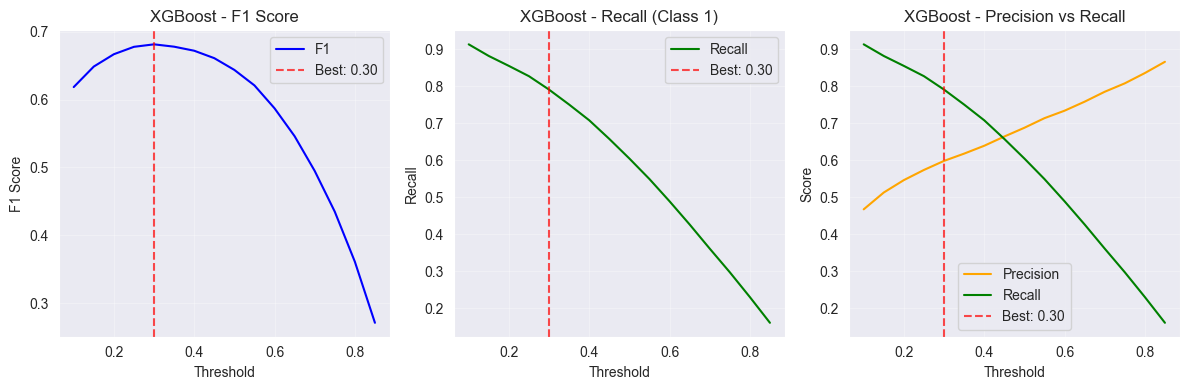


모델: RandomForest

[기본 Threshold 0.5 성능]
Train - Accuracy: 1.0000, F1: 1.0000, Recall(클래스1): 1.0000
Valid - Accuracy: 0.8283, F1: 0.5830, Recall(클래스1): 0.4822
Test  - Accuracy: 0.8252, F1: 0.5746, Recall(클래스1): 0.4744

[Threshold 최적화 결과]
F1 최대 threshold: 0.35 (F1: 0.6717, Recall: 0.7271)
Recall 최대 threshold: 0.10 (F1: 0.5170, Recall: 0.9655)
균형 잡힌 threshold: 0.35 (F1: 0.6717, Recall: 0.7271)

[최적 Threshold 0.35 성능]
Train - Accuracy: 0.9996, F1: 0.9992, Recall(클래스1): 1.0000
Valid - Accuracy: 0.8231, F1: 0.6717, Recall(클래스1): 0.7271
Test  - Accuracy: 0.8201, F1: 0.6663, Recall(클래스1): 0.7217

[Test Set 분류 리포트 - 최적 Threshold]
              precision    recall  f1-score   support

           0       0.90      0.85      0.88     27778
           1       0.62      0.72      0.67      9205

    accuracy                           0.82     36983
   macro avg       0.76      0.79      0.77     36983
weighted avg       0.83      0.82      0.82     36983


[Test Set 혼동 행렬 - 최적 Threshold]
[[23687  4

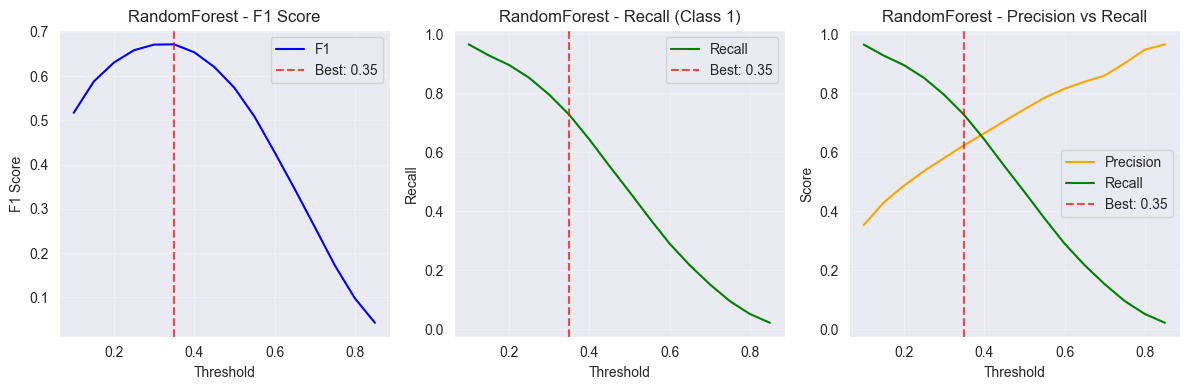


모델: DecisionTree

[기본 Threshold 0.5 성능]
Train - Accuracy: 1.0000, F1: 1.0000, Recall(클래스1): 1.0000
Valid - Accuracy: 0.7681, F1: 0.5371, Recall(클래스1): 0.5407
Test  - Accuracy: 0.7645, F1: 0.5321, Recall(클래스1): 0.5381

[Threshold 최적화 결과]
F1 최대 threshold: 0.10 (F1: 0.5371, Recall: 0.5407)
Recall 최대 threshold: 0.10 (F1: 0.5371, Recall: 0.5407)
균형 잡힌 threshold: 0.10 (F1: 0.5371, Recall: 0.5407)

[최적 Threshold 0.10 성능]
Train - Accuracy: 1.0000, F1: 1.0000, Recall(클래스1): 1.0000
Valid - Accuracy: 0.7681, F1: 0.5371, Recall(클래스1): 0.5407
Test  - Accuracy: 0.7645, F1: 0.5321, Recall(클래스1): 0.5381

[Test Set 분류 리포트 - 최적 Threshold]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84     27778
           1       0.53      0.54      0.53      9205

    accuracy                           0.76     36983
   macro avg       0.69      0.69      0.69     36983
weighted avg       0.77      0.76      0.77     36983


[Test Set 혼동 행렬 - 최적 Threshold]
[[23320  4

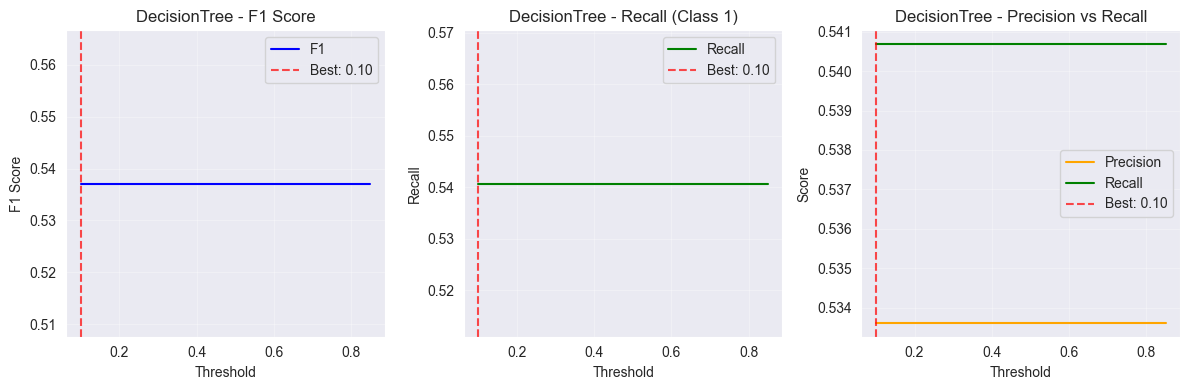

In [86]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

# 모델 정의
models = {
    'XGBoost': XGBClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

# 결과 저장용 딕셔너리
results = {}

# 각 모델 학습 및 평가
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"모델: {name}")
    print('='*60)

    # 모델 학습
    model.fit(X_train_scaled, y_train)

    # 예측 확률
    train_proba = model.predict_proba(X_train_scaled)[:, 1]  # 클래스 1의 확률
    valid_proba = model.predict_proba(X_valid_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    # 기본 threshold 0.5로 예측
    train_pred_default = (train_proba >= 0.5).astype(int)
    valid_pred_default = (valid_proba >= 0.5).astype(int)
    test_pred_default = (test_proba >= 0.5).astype(int)

    # 기본 성능
    print(f"\n[기본 Threshold 0.5 성능]")
    print(f"Train - Accuracy: {accuracy_score(y_train, train_pred_default):.4f}, "
          f"F1: {f1_score(y_train, train_pred_default):.4f}, "
          f"Recall(클래스1): {recall_score(y_train, train_pred_default):.4f}")
    print(f"Valid - Accuracy: {accuracy_score(y_valid, valid_pred_default):.4f}, "
          f"F1: {f1_score(y_valid, valid_pred_default):.4f}, "
          f"Recall(클래스1): {recall_score(y_valid, valid_pred_default):.4f}")
    print(f"Test  - Accuracy: {accuracy_score(y_test, test_pred_default):.4f}, "
          f"F1: {f1_score(y_test, test_pred_default):.4f}, "
          f"Recall(클래스1): {recall_score(y_test, test_pred_default):.4f}")

    # Threshold 최적화 (validation set 기준)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_threshold = 0.5
    best_f1 = 0
    best_recall = 0

    threshold_results = []

    for threshold in thresholds:
        valid_pred_thresh = (valid_proba >= threshold).astype(int)

        f1 = f1_score(y_valid, valid_pred_thresh)
        recall = recall_score(y_valid, valid_pred_thresh)
        precision = precision_score(y_valid, valid_pred_thresh)
        accuracy = accuracy_score(y_valid, valid_pred_thresh)

        threshold_results.append({
            'threshold': threshold,
            'f1': f1,
            'recall': recall,
            'precision': precision,
            'accuracy': accuracy
        })

    # 결과를 DataFrame으로 변환
    threshold_df = pd.DataFrame(threshold_results)

    # 최적 threshold 선택 (여러 기준 제시)
    best_f1_idx = threshold_df['f1'].idxmax()
    best_recall_idx = threshold_df['recall'].idxmax()

    # recall을 우선시하되 f1도 고려한 threshold 찾기
    # recall >= 0.7이면서 f1이 최대인 threshold
    high_recall_mask = threshold_df['recall'] >= 0.7
    if high_recall_mask.sum() > 0:
        best_balanced_idx = threshold_df[high_recall_mask]['f1'].idxmax()
        best_threshold = threshold_df.loc[best_balanced_idx, 'threshold']
    else:
        # recall 0.7 이상이 없으면 recall이 최대인 threshold 사용
        best_threshold = threshold_df.loc[best_recall_idx, 'threshold']

    print(f"\n[Threshold 최적화 결과]")
    print(f"F1 최대 threshold: {threshold_df.loc[best_f1_idx, 'threshold']:.2f} "
          f"(F1: {threshold_df.loc[best_f1_idx, 'f1']:.4f}, "
          f"Recall: {threshold_df.loc[best_f1_idx, 'recall']:.4f})")

    print(f"Recall 최대 threshold: {threshold_df.loc[best_recall_idx, 'threshold']:.2f} "
          f"(F1: {threshold_df.loc[best_recall_idx, 'f1']:.4f}, "
          f"Recall: {threshold_df.loc[best_recall_idx, 'recall']:.4f})")

    print(f"균형 잡힌 threshold: {best_threshold:.2f} "
          f"(F1: {threshold_df[threshold_df['threshold'] == best_threshold]['f1'].iloc[0]:.4f}, "
          f"Recall: {threshold_df[threshold_df['threshold'] == best_threshold]['recall'].iloc[0]:.4f})")

    # 최적 threshold로 최종 예측
    train_pred_optimal = (train_proba >= best_threshold).astype(int)
    valid_pred_optimal = (valid_proba >= best_threshold).astype(int)
    test_pred_optimal = (test_proba >= best_threshold).astype(int)

    # 최적 threshold 성능
    print(f"\n[최적 Threshold {best_threshold:.2f} 성능]")
    train_f1_opt = f1_score(y_train, train_pred_optimal)
    train_recall_opt = recall_score(y_train, train_pred_optimal)
    train_acc_opt = accuracy_score(y_train, train_pred_optimal)

    valid_f1_opt = f1_score(y_valid, valid_pred_optimal)
    valid_recall_opt = recall_score(y_valid, valid_pred_optimal)
    valid_acc_opt = accuracy_score(y_valid, valid_pred_optimal)

    test_f1_opt = f1_score(y_test, test_pred_optimal)
    test_recall_opt = recall_score(y_test, test_pred_optimal)
    test_acc_opt = accuracy_score(y_test, test_pred_optimal)

    print(f"Train - Accuracy: {train_acc_opt:.4f}, F1: {train_f1_opt:.4f}, Recall(클래스1): {train_recall_opt:.4f}")
    print(f"Valid - Accuracy: {valid_acc_opt:.4f}, F1: {valid_f1_opt:.4f}, Recall(클래스1): {valid_recall_opt:.4f}")
    print(f"Test  - Accuracy: {test_acc_opt:.4f}, F1: {test_f1_opt:.4f}, Recall(클래스1): {test_recall_opt:.4f}")

    print(f"\n[Test Set 분류 리포트 - 최적 Threshold]")
    print(classification_report(y_test, test_pred_optimal))

    print(f"\n[Test Set 혼동 행렬 - 최적 Threshold]")
    print(confusion_matrix(y_test, test_pred_optimal))

    # 결과 저장
    results[name] = {
        'model': model,
        'best_threshold': best_threshold,
        'default_threshold': {
            'train_accuracy': accuracy_score(y_train, train_pred_default),
            'valid_accuracy': accuracy_score(y_valid, valid_pred_default),
            'test_accuracy': accuracy_score(y_test, test_pred_default),
            'test_f1': f1_score(y_test, test_pred_default),
            'test_recall': recall_score(y_test, test_pred_default)
        },
        'optimal_threshold': {
            'train_accuracy': train_acc_opt,
            'valid_accuracy': valid_acc_opt,
            'test_accuracy': test_acc_opt,
            'test_f1': test_f1_opt,
            'test_recall': test_recall_opt
        },
        'threshold_results': threshold_df
    }

    # Threshold별 성능 시각화 (선택사항)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(threshold_df['threshold'], threshold_df['f1'], 'b-', label='F1')
    plt.axvline(x=best_threshold, color='r', linestyle='--', alpha=0.7, label=f'Best: {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title(f'{name} - F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(threshold_df['threshold'], threshold_df['recall'], 'g-', label='Recall')
    plt.axvline(x=best_threshold, color='r', linestyle='--', alpha=0.7, label=f'Best: {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('Recall')
    plt.title(f'{name} - Recall (Class 1)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(threshold_df['threshold'], threshold_df['precision'], 'orange', label='Precision')
    plt.plot(threshold_df['threshold'], threshold_df['recall'], 'g-', label='Recall')
    plt.axvline(x=best_threshold, color='r', linestyle='--', alpha=0.7, label=f'Best: {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'{name} - Precision vs Recall')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [87]:
# 결과 저장용 딕셔너리
results = {}

# 각 모델 학습 및 평가
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"모델: {name}")
    print('='*50)

    # 모델 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    train_pred = model.predict(X_train_scaled)
    valid_pred = model.predict(X_valid_scaled)
    test_pred = model.predict(X_test_scaled)

    # 정확도 계산
    train_acc = accuracy_score(y_train, train_pred)
    valid_acc = accuracy_score(y_valid, valid_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # 결과 저장
    results[name] = {
        'train_accuracy': train_acc,
        'valid_accuracy': valid_acc,
        'test_accuracy': test_acc,
        'model': model
    }

    # 결과 출력
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Valid Accuracy: {valid_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    print(f"\n[Test Set 분류 리포트]")
    print(classification_report(y_test, test_pred))

    print(f"\n[Test Set 혼동 행렬]")
    print(confusion_matrix(y_test, test_pred))


모델: XGBoost
Train Accuracy: 0.8804
Valid Accuracy: 0.8334
Test Accuracy: 0.8314

[Test Set 분류 리포트]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     27778
           1       0.68      0.60      0.64      9205

    accuracy                           0.83     36983
   macro avg       0.78      0.75      0.76     36983
weighted avg       0.83      0.83      0.83     36983


[Test Set 혼동 행렬]
[[25235  2543]
 [ 3694  5511]]

모델: RandomForest
Train Accuracy: 1.0000
Valid Accuracy: 0.8276
Test Accuracy: 0.8249

[Test Set 분류 리포트]
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     27778
           1       0.74      0.46      0.57      9205

    accuracy                           0.82     36983
   macro avg       0.79      0.70      0.73     36983
weighted avg       0.82      0.82      0.81     36983


[Test Set 혼동 행렬]
[[26299  1479]
 [ 4998  4207]]

모델: DecisionTree
Train Accuracy: 1.0000
Va

In [52]:
# 결과 요약 DataFrame 생성
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train_Accuracy': [results[model]['train_accuracy'] for model in results.keys()],
    'Valid_Accuracy': [results[model]['valid_accuracy'] for model in results.keys()],
    'Test_Accuracy': [results[model]['test_accuracy'] for model in results.keys()]
})

# 성능순으로 정렬
summary_df = summary_df.sort_values('Valid_Accuracy', ascending=False)

print("\n" + "="*60)
print("최종 모델 성능 비교")
print("="*60)
print(summary_df.to_string(index=False))

# 최고 성능 모델
best_model_name = summary_df.iloc[0]['Model']
print(f"\n최고 성능 모델: {best_model_name}")
print(f"검증 정확도: {summary_df.iloc[0]['Valid_Accuracy']:.4f}")
print(f"테스트 정확도: {summary_df.iloc[0]['Test_Accuracy']:.4f}")


최종 모델 성능 비교
              Model  Train_Accuracy  Valid_Accuracy  Test_Accuracy
Logistic Regression        0.836754        0.834113       0.834032
           CatBoost        0.831589        0.833951       0.832220
                MLP        0.845794        0.827434       0.823595
      Random Forest        0.869742        0.825163       0.824135
            XGBoost        0.801819        0.800909       0.797772
           LightGBM        0.788705        0.789606       0.788254

최고 성능 모델: Logistic Regression
검증 정확도: 0.8341
테스트 정확도: 0.8340


---

In [56]:
from sklearn.metrics import f1_score, precision_score, recall_score

# threshold 설정
threshold = 0.2

# 결과 저장용 딕셔너리
results = {}

# 각 모델 학습 및 평가
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"모델: {name} (Threshold: {threshold})")
    print('='*60)

    # 모델 학습 (threshold와 무관하게 동일)
    model.fit(X_train_scaled, y_train)

    # 확률 예측
    train_proba = model.predict_proba(X_train_scaled)[:, 1]  # 클래스 1의 확률
    valid_proba = model.predict_proba(X_valid_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    # 기본 threshold 0.5로 예측
    train_pred_default = (train_proba >= 0.5).astype(int)
    valid_pred_default = (valid_proba >= 0.5).astype(int)
    test_pred_default = (test_proba >= 0.5).astype(int)

    # 조정된 threshold 0.2로 예측
    train_pred_adjusted = (train_proba >= threshold).astype(int)
    valid_pred_adjusted = (valid_proba >= threshold).astype(int)
    test_pred_adjusted = (test_proba >= threshold).astype(int)

    # 성능 계산 - 기본 threshold (0.5)
    train_acc_default = accuracy_score(y_train, train_pred_default)
    valid_acc_default = accuracy_score(y_valid, valid_pred_default)
    test_acc_default = accuracy_score(y_test, test_pred_default)

    train_f1_default = f1_score(y_train, train_pred_default)
    valid_f1_default = f1_score(y_valid, valid_pred_default)
    test_f1_default = f1_score(y_test, test_pred_default)

    test_precision_default = precision_score(y_test, test_pred_default)
    test_recall_default = recall_score(y_test, test_pred_default)

    # 성능 계산 - 조정된 threshold (0.2)
    train_acc_adjusted = accuracy_score(y_train, train_pred_adjusted)
    valid_acc_adjusted = accuracy_score(y_valid, valid_pred_adjusted)
    test_acc_adjusted = accuracy_score(y_test, test_pred_adjusted)

    train_f1_adjusted = f1_score(y_train, train_pred_adjusted)
    valid_f1_adjusted = f1_score(y_valid, valid_pred_adjusted)
    test_f1_adjusted = f1_score(y_test, test_pred_adjusted)

    test_precision_adjusted = precision_score(y_test, test_pred_adjusted)
    test_recall_adjusted = recall_score(y_test, test_pred_adjusted)

    # 결과 저장
    results[name] = {
        'model': model,
        'default_threshold': {
            'train_accuracy': train_acc_default,
            'valid_accuracy': valid_acc_default,
            'test_accuracy': test_acc_default,
            'train_f1': train_f1_default,
            'valid_f1': valid_f1_default,
            'test_f1': test_f1_default,
            'test_precision': test_precision_default,
            'test_recall': test_recall_default
        },
        'adjusted_threshold': {
            'train_accuracy': train_acc_adjusted,
            'valid_accuracy': valid_acc_adjusted,
            'test_accuracy': test_acc_adjusted,
            'train_f1': train_f1_adjusted,
            'valid_f1': valid_f1_adjusted,
            'test_f1': test_f1_adjusted,
            'test_precision': test_precision_adjusted,
            'test_recall': test_recall_adjusted
        }
    }

    # 결과 출력
    print(f"\n[기본 Threshold 0.5 결과]")
    print(f"Train - Accuracy: {train_acc_default:.4f}, F1: {train_f1_default:.4f}")
    print(f"Valid - Accuracy: {valid_acc_default:.4f}, F1: {valid_f1_default:.4f}")
    print(f"Test  - Accuracy: {test_acc_default:.4f}, F1: {test_f1_default:.4f}")
    print(f"Test  - Precision: {test_precision_default:.4f}, Recall: {test_recall_default:.4f}")

    print(f"\n[조정된 Threshold {threshold} 결과]")
    print(f"Train - Accuracy: {train_acc_adjusted:.4f}, F1: {train_f1_adjusted:.4f}")
    print(f"Valid - Accuracy: {valid_acc_adjusted:.4f}, F1: {valid_f1_adjusted:.4f}")
    print(f"Test  - Accuracy: {test_acc_adjusted:.4f}, F1: {test_f1_adjusted:.4f}")
    print(f"Test  - Precision: {test_precision_adjusted:.4f}, Recall: {test_recall_adjusted:.4f}")

    print(f"\n[Test Set 상세 분류 리포트 - Threshold {threshold}]")
    print(classification_report(y_test, test_pred_adjusted))

    print(f"\n[Test Set 혼동 행렬 - Threshold {threshold}]")
    print(confusion_matrix(y_test, test_pred_adjusted))

    # Recall 개선 확인
    recall_improvement = test_recall_adjusted - test_recall_default
    print(f"\nRecall 개선: {test_recall_default:.4f} → {test_recall_adjusted:.4f} (+{recall_improvement:.4f})")


모델: XGBoost (Threshold: 0.2)

[기본 Threshold 0.5 결과]
Train - Accuracy: 0.8804, F1: 0.7442
Valid - Accuracy: 0.8334, F1: 0.6438
Test  - Accuracy: 0.8314, F1: 0.6386
Test  - Precision: 0.6843, Recall: 0.5987

[조정된 Threshold 0.2 결과]
Train - Accuracy: 0.8139, F1: 0.7084
Valid - Accuracy: 0.7874, F1: 0.6669
Test  - Accuracy: 0.7843, F1: 0.6628
Test  - Precision: 0.5424, Recall: 0.8518

[Test Set 상세 분류 리포트 - Threshold 0.2]
              precision    recall  f1-score   support

           0       0.94      0.76      0.84     27778
           1       0.54      0.85      0.66      9205

    accuracy                           0.78     36983
   macro avg       0.74      0.81      0.75     36983
weighted avg       0.84      0.78      0.80     36983


[Test Set 혼동 행렬 - Threshold 0.2]
[[21164  6614]
 [ 1364  7841]]

Recall 개선: 0.5987 → 0.8518 (+0.2531)

모델: RandomForest (Threshold: 0.2)

[기본 Threshold 0.5 결과]
Train - Accuracy: 1.0000, F1: 1.0000
Valid - Accuracy: 0.8283, F1: 0.5830
Test  - Accuracy:

---

In [18]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier

# 1. 범주형 컬럼만 추출
cat_cols = df.select_dtypes(include=['object']).columns

# object 타입 컬럼들 + 섞여 있는 경우 모두 문자열로 변환
for col in cat_cols:
    df[col] = df[col].astype(str)

# NaN → 'MISSING' (임시 값)
df[cat_cols] = df[cat_cols].replace("nan", "MISSING")  # astype(str) 후 NaN이 'nan' 문자열로 변환됨

# 2. 인코딩
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# 3. 결측치가 있는 컬럼 추출
cols_with_missing = df.columns[df.isnull().any()].tolist()

# 4. IterativeImputer + RFClassifier
if cols_with_missing:  # 결측치가 실제로 있을 때만 실행
    imputer = IterativeImputer(
        estimator=RandomForestClassifier(n_estimators=50, random_state=42),
        max_iter=10,
        random_state=42
    )
    df[cols_with_missing] = imputer.fit_transform(df[cols_with_missing])

# 5. 인코딩 되돌리기
df[cat_cols] = encoder.inverse_transform(df[cat_cols])


KeyboardInterrupt: 

In [ ]:
# 3. 인코딩 (Encoding)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Ordinal 컬럼 라벨 인코딩
label_encoders = {}
for col in ordinal_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Nominal 컬럼 더미변수화 (One-Hot Encoding)
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# 4. 스케일링 (Scaling)
from sklearn.preprocessing import StandardScaler

# 스케일링할 컬럼 리스트 정의 (인코딩된 컬럼과 더미변수 제외)
cols_to_scale = [col for col in df.columns if col not in ordinal_cols and 'city_' not in col and 'job_title_' not in col]
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 'target' 컬럼을 예측 목표로 가정
X = df.drop('target', axis=1)
y = df['target']

# train:valid:test = 60:20:20 비율로 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"훈련 데이터 크기: {len(X_train)}")
print(f"검증 데이터 크기: {len(X_valid)}")
print(f"테스트 데이터 크기: {len(X_test)}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 모델 리스트 정의
models = {
    'XGBoost': XGBClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

results = {}

# 각 모델을 훈련시키고 검증 데이터로 성능 평가
for name, model in models.items():
    print(f"---- {name} 모델 훈련 시작 ----")
    model.fit(X_train, y_train)
    y_pred_valid = model.predict(X_valid)
    valid_accuracy = accuracy_score(y_valid, y_pred_valid)
    results[name] = valid_accuracy
    print(f"{name} 검증 데이터 정확도: {valid_accuracy:.4f}\n")

# 검증 정확도 결과 출력
print("모델별 검증 정확도:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# 가장 성능이 좋은 모델 선택
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n최고 성능 모델: {best_model_name}")

# 최종 테스트 데이터로 성능 평가
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"최종 {best_model_name} 모델의 테스트 데이터 정확도: {test_accuracy:.4f}")

---

In [75]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [77]:
def save_preprocessed_data(df_processed, label_encoders, scaler, save_path="preprocessed_data"):
    """
    전처리된 데이터와 변환 객체들을 저장
    """
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # 데이터프레임 저장
    df_processed.to_csv(f"{save_path}/processed_data.csv", index=False)

    # 인코더와 스케일러 저장
    with open(f"{save_path}/label_encoders.pkl", 'wb') as f:
        pickle.dump(label_encoders, f)

    with open(f"{save_path}/scaler.pkl", 'wb') as f:
        pickle.dump(scaler, f)

    print(f"✅ 전처리된 데이터가 '{save_path}' 폴더에 저장되었습니다.")

def load_preprocessed_data(save_path="preprocessed_data"):
    """
    저장된 전처리 데이터와 변환 객체들을 불러오기
    """
    try:
        # 데이터프레임 불러오기
        df_processed = pd.read_csv(f"{save_path}/processed_data.csv")

        # 인코더와 스케일러 불러오기
        with open(f"{save_path}/label_encoders.pkl", 'rb') as f:
            label_encoders = pickle.load(f)

        with open(f"{save_path}/scaler.pkl", 'rb') as f:
            scaler = pickle.load(f)

        print(f"✅ '{save_path}'에서 전처리된 데이터를 불러왔습니다.")
        print(f"데이터 shape: {df_processed.shape}")

        return df_processed, label_encoders, scaler

    except FileNotFoundError:
        print(f"❌ '{save_path}' 경로에 저장된 데이터가 없습니다.")
        return None, None, None

def check_preprocessed_data_exists(save_path="preprocessed_data"):
    """
    전처리된 데이터가 존재하는지 확인
    """
    required_files = [
        f"{save_path}/processed_data.csv",
        f"{save_path}/label_encoders.pkl",
        f"{save_path}/scaler.pkl"
    ]

    return all(os.path.exists(file) for file in required_files)

In [65]:
def preprocess_data(df, target_col, numeric_cols, nominal_cols, ordinal_cols):
    """
    데이터 전처리 함수
    """
    print("=== 데이터 전처리 시작 ===")

    # 원본 데이터 복사
    df_processed = df.copy()

    # 1. 결측 비율이 50% 이상인 컬럼 제거
    print("1. 결측 비율 50% 이상 컬럼 제거")
    missing_rate = df_processed.isnull().mean()
    drop_cols = missing_rate[missing_rate > 0.5].index
    print(f"제거할 컬럼 수: {len(drop_cols)}")
    if len(drop_cols) > 0:
        print(f"제거할 컬럼: {list(drop_cols)}")
        df_processed.drop(columns=drop_cols, inplace=True)

        # 제거된 컬럼들을 각 타입별 리스트에서도 제거
        numeric_cols = [col for col in numeric_cols_original if col not in drop_cols]
        nominal_cols = [col for col in nominal_cols_original if col not in drop_cols]
        ordinal_cols = [col for col in ordinal_cols_original if col not in drop_cols]

    # 2. 결측치 처리
    print("\n2. 결측치 처리")

    # 2-1. Numeric 컬럼: 최빈값으로 채우기
    print("2-1. Numeric 컬럼 최빈값으로 결측치 채우기")
    for col in numeric_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed[col].fillna(mode_val[0], inplace=True)
                print(f"  - {col}: {mode_val[0]}로 채움")

    # 2-2. Nominal과 Ordinal 컬럼: RandomForest로 채우기
    print("2-2. Nominal/Ordinal 컬럼 RandomForest로 결측치 채우기")
    cat_cols_with_missing = []
    for col in nominal_cols + ordinal_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            cat_cols_with_missing.append(col)

    for col in cat_cols_with_missing:
        missing_idx = df_processed[col].isnull()
        if missing_idx.sum() == 0:
            continue

        print(f"  처리 중: {col} ({missing_idx.sum()}개 결측치)")

        # feature 컬럼 (target과 현재 컬럼 제외)
        feature_cols = [c for c in df_processed.columns if c != col and c != target_col]

        # 학습/예측용 데이터 준비
        train_data = df_processed.loc[~missing_idx, feature_cols].copy()
        pred_data = df_processed.loc[missing_idx, feature_cols].copy()

        # 각 feature 컬럼별 전처리
        for feat_col in feature_cols:
            if df_processed[feat_col].dtype in ['int64', 'int32', 'float64', 'float32']:
                median_val = df_processed[feat_col].median()
                train_data[feat_col] = train_data[feat_col].fillna(median_val)
                pred_data[feat_col] = pred_data[feat_col].fillna(median_val)
            else:
                train_data[feat_col] = train_data[feat_col].fillna('Unknown').astype(str)
                pred_data[feat_col] = pred_data[feat_col].fillna('Unknown').astype(str)

        # 원핫인코딩
        X_train = pd.get_dummies(train_data, dummy_na=False)
        X_pred = pd.get_dummies(pred_data, dummy_na=False)

        # 컬럼 맞추기
        for col_name in X_train.columns:
            if col_name not in X_pred.columns:
                X_pred[col_name] = 0
        for col_name in X_pred.columns:
            if col_name not in X_train.columns:
                X_train[col_name] = 0
        X_pred = X_pred[X_train.columns]

        # 타겟 변수
        y_train = df_processed.loc[~missing_idx, col].astype(str)

        try:
            # RF 모델로 예측
            rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
            rf_model.fit(X_train, y_train)
            predictions = rf_model.predict(X_pred)

            # 원래 데이터 타입 복원
            if df_processed[col].dtype in ['int64', 'int32']:
                try:
                    predictions = predictions.astype(int)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0).astype(int)
            elif df_processed[col].dtype in ['float64', 'float32']:
                try:
                    predictions = predictions.astype(float)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0.0)

            df_processed.loc[missing_idx, col] = predictions
            print(f"    ✅ 완료")

        except Exception as e:
            print(f"    ❌ 오류 발생: {str(e)}")
            # 최빈값으로 대체
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed.loc[missing_idx, col] = mode_val[0]
                print(f"    → 최빈값으로 대체")

    # 3. 인코딩
    print("\n3. 인코딩 처리")

    # Label Encoder 저장용
    label_encoders = {}

    # 3-1. Nominal 컬럼: 라벨 인코딩
    print("3-1. Nominal 컬럼 라벨 인코딩")
    for col in nominal_cols:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"  - {col} 라벨 인코딩 완료")

    # 3-2. Ordinal 컬럼: 더미변수화
    print("3-2. Ordinal 컬럼 더미변수화")
    ordinal_cols_in_data = [col for col in ordinal_cols if col in df_processed.columns]
    if ordinal_cols_in_data:
        df_processed = pd.get_dummies(df_processed, columns=ordinal_cols_in_data, dummy_na=False)
        print(f"  - {len(ordinal_cols_in_data)}개 컬럼 더미변수화 완료")

    # ★★★ 디버깅 코드 ★★★
    print("\n=== 스케일링 전 데이터 타입 체크 ===")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]

    # 각 컬럼의 데이터 타입과 고유값 확인
    problem_cols = []
    for col in feature_cols_for_scaling:
        dtype = df_processed[col].dtype
        unique_vals = df_processed[col].unique()

        print(f"{col}: {dtype}")

        # 문자열 타입이거나 숫자로 변환할 수 없는 값이 있는지 체크
        if dtype == 'object' or dtype == 'string':
            print(f"  ⚠️  경고: {col}은 여전히 문자열 타입입니다!")
            print(f"  고유값 (최대 10개): {unique_vals[:10]}")
            problem_cols.append(col)

        # 숫자 타입이어도 실제로 문자열이 섞여있는지 체크
        elif dtype in ['int64', 'float64']:
            try:
                pd.to_numeric(df_processed[col], errors='raise')
            except:
                print(f"  ⚠️  경고: {col}에 숫자로 변환할 수 없는 값이 있습니다!")
                print(f"  고유값 (최대 10개): {unique_vals[:10]}")
                problem_cols.append(col)

    print(f"\n=== 문제가 있는 컬럼들을 추가로 처리 ({len(problem_cols)}개) ===")

    # 여전히 문자열 타입인 컬럼들을 라벨 인코딩으로 처리
    for col in problem_cols:
        if df_processed[col].dtype == 'object':
            print(f"문자열 컬럼 {col}을 라벨 인코딩으로 처리합니다.")
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[f'{col}_auto'] = le

    # 4. 스케일링 (타겟 컬럼 제외)
    print("\n4. 스케일링 처리")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]

    scaler = StandardScaler()
    df_processed[feature_cols_for_scaling] = scaler.fit_transform(df_processed[feature_cols_for_scaling])
    print("  - 스케일링 완료")

    print("\n=== 데이터 전처리 완료 ===\n")

    return df_processed, label_encoders, scaler

def train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    모델 학습 및 평가 함수
    """
    # 모델 정의
    models = [
        ("XGBoost", XGBClassifier(random_state=42, eval_metric='logloss')),
        ("RandomForest", RandomForestClassifier(random_state=42, n_jobs=-1)),
        ("DecisionTree", DecisionTreeClassifier(random_state=42))
    ]

    results = {}

    print("=== 모델 학습 및 평가 ===")

    for model_name, model in models:
        print(f"\n{model_name} 학습 중...")

        # 모델 학습
        model.fit(X_train, y_train)

        # 예측
        train_pred = model.predict(X_train)
        valid_pred = model.predict(X_valid)
        test_pred = model.predict(X_test)

        # 정확도 계산
        train_acc = accuracy_score(y_train, train_pred)
        valid_acc = accuracy_score(y_valid, valid_pred)
        test_acc = accuracy_score(y_test, test_pred)

        results[model_name] = {
            'model': model,
            'train_accuracy': train_acc,
            'valid_accuracy': valid_acc,
            'test_accuracy': test_acc,
            'predictions': {
                'train': train_pred,
                'valid': valid_pred,
                'test': test_pred
            }
        }

        print(f"{model_name} 결과:")
        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Valid Accuracy: {valid_acc:.4f}")
        print(f"  Test Accuracy: {test_acc:.4f}")

        # Test set에 대한 상세 결과
        print(f"\n{model_name} Test Set Classification Report:")
        print(classification_report(y_test, test_pred))

    return results
#
# def main(df, target_col, numeric_cols, nominal_cols, ordinal_cols, test_size=0.2, valid_size=0.2):
#     """
#     전체 파이프라인 실행
#     """
#     # 1. 데이터 전처리
#     df_processed, label_encoders, scaler = preprocess_data(
#         df, target_col, numeric_cols, nominal_cols, ordinal_cols
#     )
#
#     # 2. 특성과 타겟 분리
#     X = df_processed.drop(columns=[target_col])
#     y = df_processed[target_col]
#
#     # 3. 데이터 분할
#     print("=== 데이터 분할 ===")
#     # 먼저 train과 temp로 분할
#     X_train, X_temp, y_train, y_temp = train_test_split(
#         X, y, test_size=test_size+valid_size, random_state=42, stratify=y
#     )
#
#     # temp를 valid와 test로 분할
#     X_valid, X_test, y_valid, y_test = train_test_split(
#         X_temp, y_temp, test_size=test_size/(test_size+valid_size), random_state=42, stratify=y_temp
#     )
#
#     print(f"Train set: {X_train.shape[0]} samples")
#     print(f"Valid set: {X_valid.shape[0]} samples")
#     print(f"Test set: {X_test.shape[0]} samples")
#
#     # 4. 모델 학습 및 평가
#     results = train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test)
#
#     # 5. 결과 요약
#     print("\n=== 최종 결과 요약 ===")
#     for model_name, result in results.items():
#         print(f"{model_name}: Test Accuracy = {result['test_accuracy']:.4f}")
#
#     return results, df_processed, label_encoders, scaler
#
# # ============= 실행 부분 =============
#
# target_col = '기부여부'  # 실제 타겟 컬럼명으로 수정
#
# # 실행
# results, processed_data, encoders, scaler = main(
#     df, target_col, numeric_cols_original, nominal_cols_original, ordinal_cols_original
# )
#
# # 추가 분석 (선택사항)
# print("\n=== 추가 정보 ===")
# print(f"전처리된 데이터 shape: {processed_data.shape}")
# print(f"Feature 개수: {processed_data.shape[1] - 1}")  # 타겟 컬럼 제외
#
# # 최고 성능 모델 확인
# best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'])
# print(f"최고 성능 모델: {best_model[0]} (Test Accuracy: {best_model[1]['test_accuracy']:.4f})")

=== 데이터 전처리 시작 ===
1. 결측 비율 50% 이상 컬럼 제거
제거할 컬럼 수: 273
제거할 컬럼: ['재학학년', '사회보험료부담인식_건강보험부담정도', '사회보험료부담인식_국민연금부담정도', '사회보험료부담인식_고용보험부담정도', '장애인견해', '노후준비방법_부수적방법', '노후준비방법_노후미준비사유', '생활비마련방법', '생활비마련방법_본인및배우자부담', '생활비마련방법_지원자녀및친척동거여부', '현재자녀동거여부', '현재자녀동거사유_1순위', '현재자녀동거사유_2순위', '현재자녀동거사유_3순위', '현재자녀비동거사유_1순위', '현재자녀비동거사유_2순위', '현재자녀비동거사유_3순위', '향후자녀동거의향여부', '향후희망거처', '사회적관계망_자금차입도움요청대상인원수', '단체참여여부', '참여단체_1순위', '참여단체_2순위', '참여단체_3순위', '기부희망분야_1순위', '기부희망분야_2순위', '기부희망분야_3순위', '자원봉사활동_아동청소년노인장애인재소자관련횟수', '자원봉사활동_아동청소년노인장애인재소자관련시간수', '자원봉사활동_환경보전범죄예방관련횟수', '자원봉사활동_환경보전범죄예방관련시간수', '자원봉사활동_자녀교육관련횟수', '자원봉사활동_자녀교육관련시간수', '자원봉사활동_국가및지역행사관련횟수', '자원봉사활동_국가및지역행사관련시간수', '자원봉사활동_재해지역주민돕기및시설복구관련횟수', '자원봉사활동_재해지역주민돕기및시설복구관련시간수', '자원봉사활동_기타일반봉사관련횟수', '자원봉사활동_기타일반봉사관련시간수', '자원봉사활동정기성여부', '자원봉사활동정기성주기', '자원봉사활동인지경로', '전문성활용자원봉사활동_참석여부', '전문성활용자원봉사활동_내용', '독서_잡지류권수', '독서_교양서적권수', '독서_직업직무관련서적권수', '독서_생활취미정보서적권수', '독서_기타권수', '문화예술스포츠관람_음악연주회콘서트횟수', '문화예술스포츠관람_연극마당극뮤지컬횟수', '문화예술스포츠관람_무용횟수', '문화예술스포츠관람_영

In [79]:
def main_with_cache(df, target_col, numeric_cols, nominal_cols, ordinal_cols,
                    test_size=0.2, valid_size=0.2, save_path="preprocessed_data",
                    force_reprocess=False):
    """
    캐시 기능이 있는 메인 함수

    Parameters:
    - force_reprocess: True면 기존 저장된 데이터 무시하고 새로 전처리
    """

    # 1. 전처리된 데이터가 이미 있는지 확인
    if not force_reprocess and check_preprocessed_data_exists(save_path):
        print("=== 저장된 전처리 데이터 발견 ===")
        user_input = input("저장된 데이터를 사용하시겠습니까? (y/n): ").lower().strip()

        if user_input in ['y', 'yes', '']:
            df_processed, label_encoders, scaler = load_preprocessed_data(save_path)
            if df_processed is not None:
                print("저장된 데이터를 사용합니다.")
            else:
                print("저장된 데이터 로드에 실패했습니다. 새로 전처리합니다.")
                df_processed, label_encoders, scaler = preprocess_data(
                    df, target_col, numeric_cols, nominal_cols, ordinal_cols
                )
                save_preprocessed_data(df_processed, label_encoders, scaler, save_path)
        else:
            print("새로 전처리를 진행합니다.")
            df_processed, label_encoders, scaler = preprocess_data(
                df, target_col, numeric_cols, nominal_cols, ordinal_cols
            )
            save_preprocessed_data(df_processed, label_encoders, scaler, save_path)
    else:
        # 새로 전처리 진행
        print("=== 새로운 전처리 진행 ===")
        df_processed, label_encoders, scaler = preprocess_data(
            df, target_col, numeric_cols, nominal_cols, ordinal_cols
        )
        save_preprocessed_data(df_processed, label_encoders, scaler, save_path)

    # 2. 특성과 타겟 분리
    X = df_processed.drop(columns=[target_col])
    y = df_processed[target_col]

    # 3. 데이터 분할
    print("=== 데이터 분할 ===")
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size+valid_size, random_state=42, stratify=y
    )

    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size/(test_size+valid_size), random_state=42, stratify=y_temp
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Valid set: {X_valid.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # 4. 모델 학습 및 평가
    results = train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test)

    # 5. 결과 요약
    print("\n=== 최종 결과 요약 ===")
    for model_name, result in results.items():
        print(f"{model_name}: Test Accuracy = {result['test_accuracy']:.4f}")

    return results, df_processed, label_encoders, scaler

# ============= 실행 부분 =============
target_col = '기부여부'

# 실행 (캐시 기능 포함)
results, processed_data, encoders, scaler = main_with_cache(
    df, target_col, numeric_cols_original, nominal_cols_original, ordinal_cols_original,
    save_path="C:/Users/Admin/PycharmProjects/DonationDiveLocal",  # 저장 경로 지정
    force_reprocess=True  # True로 하면 강제로 새로 전처리
)

print("\n=== 추가 정보 ===")
print(f"전처리된 데이터 shape: {processed_data.shape}")
print(f"Feature 개수: {processed_data.shape[1] - 1}")

best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"최고 성능 모델: {best_model[0]} (Test Accuracy: {best_model[1]['test_accuracy']:.4f})")

=== 새로운 전처리 진행 ===
=== 데이터 전처리 시작 ===
1. 결측 비율 50% 이상 컬럼 제거
제거할 컬럼 수: 273

2. 결측치 처리
2-1. Numeric 컬럼 최빈값으로 결측치 채우기
  - 사회적관계망_가사도움요청대상인원수: 1.0로 채움
  - 사회적관계망_대화상대도움요청대상인원수: 1.0로 채움
  - 레저시설_관광명소유적지국립공원이용횟수: 1.0로 채움
  - 국내관광여행_숙박여행횟수: 1.0로 채움
  - 국내관광여행_당일여행횟수: 0.0로 채움
2-2. Nominal/Ordinal 컬럼 RandomForest로 결측치 채우기
  처리 중: 긴축소비지출항목_1순위 (92385개 결측치)
    ✅ 완료
  처리 중: 노후준비방법_주된방법 (70309개 결측치)
    ✅ 완료
  처리 중: 노후희망활동 (12202개 결측치)
    ✅ 완료
  처리 중: 분류코드_맞벌이1여부 (44708개 결측치)
    ✅ 완료
  처리 중: 분류코드_맞벌이2여부 (44708개 결측치)
    ✅ 완료
  처리 중: 분류코드_산업별 (78791개 결측치)
    ✅ 완료
  처리 중: 분류코드_종사자지위 (78626개 결측치)
    ✅ 완료
  처리 중: 분류코드_직업별 (78628개 결측치)
    ✅ 완료
  처리 중: 선호장례방법 (12202개 결측치)
    ✅ 완료
  처리 중: 여성취업장애요인_2순위 (30533개 결측치)
    ✅ 완료
  처리 중: 여성취업장애요인_3순위 (73463개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_1순위 (53125개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_2순위 (60648개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_3순위 (82056개 결측치)
    ✅ 완료
  처리 중: 재학상태 (7360개 결측치)
    ✅ 완료
  처리 중: 점유형태 (92330개 결측치)
    ✅ 완료
  처리 중: 주말여가활동_동반자 (39282개 결측치

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [71]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

def preprocess_data(df, target_col, numeric_cols, nominal_cols, ordinal_cols):
    """
    데이터 전처리 함수
    """
    print("=== 데이터 전처리 시작 ===")

    # 원본 데이터 복사
    df_processed = df.copy()

    # 1. 결측 비율이 50% 이상인 컬럼 제거
    print("1. 결측 비율 50% 이상 컬럼 제거")
    missing_rate = df_processed.isnull().mean()
    drop_cols = missing_rate[missing_rate > 0.5].index
    print(f"제거할 컬럼 수: {len(drop_cols)}")
    if len(drop_cols) > 0:
        df_processed.drop(columns=drop_cols, inplace=True)

        # 제거된 컬럼들을 각 타입별 리스트에서도 제거
        numeric_cols = [col for col in numeric_cols if col not in drop_cols]
        nominal_cols = [col for col in nominal_cols if col not in drop_cols]
        ordinal_cols = [col for col in ordinal_cols if col not in drop_cols]

    # 2. 결측치 처리
    print("\n2. 결측치 처리")

    # 2-1. Numeric 컬럼: 최빈값으로 채우기
    print("2-1. Numeric 컬럼 최빈값으로 결측치 채우기")
    for col in numeric_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed[col].fillna(mode_val[0], inplace=True)
                print(f"  - {col}: {mode_val[0]}로 채움")

    # 2-2. Nominal과 Ordinal 컬럼: RandomForest로 채우기
    print("2-2. Nominal/Ordinal 컬럼 RandomForest로 결측치 채우기")
    cat_cols_with_missing = []
    for col in nominal_cols + ordinal_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            cat_cols_with_missing.append(col)

    for col in cat_cols_with_missing:
        missing_idx = df_processed[col].isnull()
        if missing_idx.sum() == 0:
            continue

        print(f"  처리 중: {col} ({missing_idx.sum()}개 결측치)")

        # feature 컬럼 (target과 현재 컬럼 제외)
        feature_cols = [c for c in df_processed.columns if c != col and c != target_col]

        # 학습/예측용 데이터 준비
        train_data = df_processed.loc[~missing_idx, feature_cols].copy()
        pred_data = df_processed.loc[missing_idx, feature_cols].copy()

        # 각 feature 컬럼별 전처리
        for feat_col in feature_cols:
            if df_processed[feat_col].dtype in ['int64', 'int32', 'float64', 'float32']:
                median_val = df_processed[feat_col].median()
                train_data[feat_col] = train_data[feat_col].fillna(median_val)
                pred_data[feat_col] = pred_data[feat_col].fillna(median_val)
            else:
                train_data[feat_col] = train_data[feat_col].fillna('Unknown').astype(str)
                pred_data[feat_col] = pred_data[feat_col].fillna('Unknown').astype(str)

        # 원핫인코딩
        X_train = pd.get_dummies(train_data, dummy_na=False)
        X_pred = pd.get_dummies(pred_data, dummy_na=False)

        # 컬럼 맞추기
        for col_name in X_train.columns:
            if col_name not in X_pred.columns:
                X_pred[col_name] = 0
        for col_name in X_pred.columns:
            if col_name not in X_train.columns:
                X_train[col_name] = 0
        X_pred = X_pred[X_train.columns]

        # 타겟 변수
        y_train = df_processed.loc[~missing_idx, col].astype(str)

        try:
            # RF 모델로 예측
            rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
            rf_model.fit(X_train, y_train)
            predictions = rf_model.predict(X_pred)

            # 원래 데이터 타입 복원
            if df_processed[col].dtype in ['int64', 'int32']:
                try:
                    predictions = predictions.astype(int)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0).astype(int)
            elif df_processed[col].dtype in ['float64', 'float32']:
                try:
                    predictions = predictions.astype(float)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0.0)

            df_processed.loc[missing_idx, col] = predictions
            print(f"    ✅ 완료")

        except Exception as e:
            print(f"    ❌ 오류 발생: {str(e)}")
            # 최빈값으로 대체
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed.loc[missing_idx, col] = mode_val[0]
                print(f"    → 최빈값으로 대체")

    # 3. 인코딩
    print("\n3. 인코딩 처리")

    # Label Encoder 저장용
    label_encoders = {}

    # 3-1. Nominal 컬럼: 더미변수화 (순서 없음)
    print("3-1. Nominal 컬럼 더미변수화")
    nominal_cols_in_data = [col for col in nominal_cols if col in df_processed.columns]
    if nominal_cols_in_data:
        df_processed = pd.get_dummies(df_processed, columns=nominal_cols_in_data, dummy_na=False)
        print(f"  - {len(nominal_cols_in_data)}개 컬럼 더미변수화 완료")

    # 3-2. Ordinal 컬럼: 라벨 인코딩 (순서 있음)
    print("3-2. Ordinal 컬럼 라벨 인코딩")
    for col in ordinal_cols:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"  - {col} 라벨 인코딩 완료")

    # ★★★ 수정된 디버깅 코드 ★★★
    print("\n=== 스케일링 전 데이터 타입 체크 ===")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]
    print(f"현재 데이터프레임 컬럼 수: {len(df_processed.columns)}")
    print(f"스케일링 대상 컬럼 수: {len(feature_cols_for_scaling)}")

    # 각 컬럼의 데이터 타입과 고유값 확인
    problem_cols = []
    for col in feature_cols_for_scaling:
        # if col not in df_processed.columns:  # 컬럼 존재 여부 확인
        #     print(f"⚠️ 컬럼 '{col}'이 데이터에 존재하지 않습니다!")
        #     continue
        print(col)
        dtype = df_processed[col].dtype
        unique_vals = df_processed[col].unique()

        print(f"{col}: {dtype}")

        # 문자열 타입이거나 숫자로 변환할 수 없는 값이 있는지 체크
        if dtype == 'object' or dtype == 'string':
            print(f"  ⚠️  경고: {col}은 여전히 문자열 타입입니다!")
            print(f"  고유값 (최대 10개): {unique_vals[:10]}")
            problem_cols.append(col)

        # 숫자 타입이어도 실제로 문자열이 섞여있는지 체크
        elif dtype in ['int64', 'float64']:
            try:
                pd.to_numeric(df_processed[col], errors='raise')
            except:
                print(f"  ⚠️  경고: {col}에 숫자로 변환할 수 없는 값이 있습니다!")
                print(f"  고유값 (최대 10개): {unique_vals[:10]}")
                problem_cols.append(col)

    print(f"\n=== 문제가 있는 컬럼들을 추가로 처리 ({len(problem_cols)}개) ===")

    # 여전히 문자열 타입인 컬럼들을 라벨 인코딩으로 처리
    for col in problem_cols:
        if df_processed[col].dtype == 'object':
            print(f"문자열 컬럼 {col}을 라벨 인코딩으로 처리합니다.")
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[f'{col}_auto'] = le

    # 4. 스케일링 (타겟 컬럼 제외)
    print("\n4. 스케일링 처리")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]

    scaler = StandardScaler()
    df_processed[feature_cols_for_scaling] = scaler.fit_transform(df_processed[feature_cols_for_scaling])
    print("  - 스케일링 완료")

    print("\n=== 데이터 전처리 완료 ===\n")

    return df_processed, label_encoders, scaler

def train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    모델 학습 및 평가 함수
    """
    # 모델 정의
    models = [
        ("XGBoost", XGBClassifier(random_state=42, eval_metric='logloss')),
        ("RandomForest", RandomForestClassifier(random_state=42, n_jobs=-1)),
        ("DecisionTree", DecisionTreeClassifier(random_state=42))
    ]

    results = {}

    print("=== 모델 학습 및 평가 ===")

    for model_name, model in models:
        print(f"\n{model_name} 학습 중...")

        # 모델 학습
        model.fit(X_train, y_train)

        # 예측
        train_pred = model.predict(X_train)
        valid_pred = model.predict(X_valid)
        test_pred = model.predict(X_test)

        # 정확도 계산
        train_acc = accuracy_score(y_train, train_pred)
        valid_acc = accuracy_score(y_valid, valid_pred)
        test_acc = accuracy_score(y_test, test_pred)

        results[model_name] = {
            'model': model,
            'train_accuracy': train_acc,
            'valid_accuracy': valid_acc,
            'test_accuracy': test_acc,
            'predictions': {
                'train': train_pred,
                'valid': valid_pred,
                'test': test_pred
            }
        }

        print(f"{model_name} 결과:")
        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Valid Accuracy: {valid_acc:.4f}")
        print(f"  Test Accuracy: {test_acc:.4f}")

        # Test set에 대한 상세 결과
        print(f"\n{model_name} Test Set Classification Report:")
        print(classification_report(y_test, test_pred))

    return results

def main(df, target_col, numeric_cols, nominal_cols, ordinal_cols, test_size=0.2, valid_size=0.2):
    """
    전체 파이프라인 실행
    """
    # 1. 데이터 전처리
    df_processed, label_encoders, scaler = preprocess_data(
        df, target_col, numeric_cols, nominal_cols, ordinal_cols
    )

    # 2. 특성과 타겟 분리
    X = df_processed.drop(columns=[target_col])
    y = df_processed[target_col]

    # 3. 데이터 분할
    print("=== 데이터 분할 ===")
    # 먼저 train과 temp로 분할
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size+valid_size, random_state=42, stratify=y
    )

    # temp를 valid와 test로 분할
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size/(test_size+valid_size), random_state=42, stratify=y_temp
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Valid set: {X_valid.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # 4. 모델 학습 및 평가
    results = train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test)

    # 5. 결과 요약
    print("\n=== 최종 결과 요약 ===")
    for model_name, result in results.items():
        print(f"{model_name}: Test Accuracy = {result['test_accuracy']:.4f}")

    return results, df_processed, label_encoders, scaler

# ============= 실행 부분 =============
target_col = '기부여부'

# 실행
results, processed_data, encoders, scaler = main(
    df, target_col, numeric_cols_original, nominal_cols_original, ordinal_cols_original
)

# 추가 분석
print("\n=== 추가 정보 ===")
print(f"전처리된 데이터 shape: {processed_data.shape}")
print(f"Feature 개수: {processed_data.shape[1] - 1}")

# 최고 성능 모델 확인
best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"최고 성능 모델: {best_model[0]} (Test Accuracy: {best_model[1]['test_accuracy']:.4f})")

=== 데이터 전처리 시작 ===
1. 결측 비율 50% 이상 컬럼 제거
제거할 컬럼 수: 273

2. 결측치 처리
2-1. Numeric 컬럼 최빈값으로 결측치 채우기
  - 사회적관계망_가사도움요청대상인원수: 1.0로 채움
  - 사회적관계망_대화상대도움요청대상인원수: 1.0로 채움
  - 레저시설_관광명소유적지국립공원이용횟수: 1.0로 채움
  - 국내관광여행_숙박여행횟수: 1.0로 채움
  - 국내관광여행_당일여행횟수: 0.0로 채움
2-2. Nominal/Ordinal 컬럼 RandomForest로 결측치 채우기
  처리 중: 긴축소비지출항목_1순위 (92385개 결측치)
    ✅ 완료
  처리 중: 노후준비방법_주된방법 (70309개 결측치)
    ✅ 완료
  처리 중: 노후희망활동 (12202개 결측치)
    ✅ 완료
  처리 중: 분류코드_맞벌이1여부 (44708개 결측치)
    ✅ 완료
  처리 중: 분류코드_맞벌이2여부 (44708개 결측치)
    ✅ 완료
  처리 중: 분류코드_산업별 (78791개 결측치)
    ✅ 완료
  처리 중: 분류코드_종사자지위 (78626개 결측치)
    ✅ 완료
  처리 중: 분류코드_직업별 (78628개 결측치)
    ✅ 완료
  처리 중: 선호장례방법 (12202개 결측치)
    ✅ 완료
  처리 중: 여성취업장애요인_2순위 (30533개 결측치)
    ✅ 완료
  처리 중: 여성취업장애요인_3순위 (73463개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_1순위 (53125개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_2순위 (60648개 결측치)
    ✅ 완료
  처리 중: 우선실시장애인복지사업_3순위 (82056개 결측치)
    ✅ 완료
  처리 중: 재학상태 (7360개 결측치)
    ✅ 완료
  처리 중: 점유형태 (92330개 결측치)
    ✅ 완료
  처리 중: 주말여가활동_동반자 (39282개 결측치)
    ✅ 완료
  처리 중: 

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [72]:
print("=== 컬럼명 디버깅 ===")
print(f"전체 컬럼 개수: {len(df_processed.columns)}")

# 직업대분류 관련 컬럼들만 확인
job_cols = [col for col in df_processed.columns if '직업대분류' in str(col)]
print(f"직업대분류 관련 컬럼들: {job_cols}")

# 각 컬럼의 정확한 이름과 타입 확인
for i, col in enumerate(df_processed.columns):
    if '직업대분류' in str(col):
        print(f"인덱스 {i}: '{col}' (길이: {len(str(col))}, 타입: {type(col)}, dtype: {df_processed[col].dtype})")

# 문제가 되는 컬럼의 실제 이름 확인
try:
    problematic_col = [col for col in df_processed.columns if '직업대분류_2.0' in str(col)][0]
    print(f"문제 컬럼의 실제 이름: '{problematic_col}'")
    print(f"문제 컬럼의 repr: {repr(problematic_col)}")
except:
    print("직업대분류_2.0 컬럼을 찾을 수 없습니다!")

=== 컬럼명 디버깅 ===


NameError: name 'df_processed' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

def preprocess_data(df, target_col, numeric_cols, nominal_cols, ordinal_cols):
    """
    데이터 전처리 함수
    """
    print("=== 데이터 전처리 시작 ===")

    # 원본 데이터 복사
    df_processed = df.copy()

    # 1. 결측 비율이 50% 이상인 컬럼 제거
    print("1. 결측 비율 50% 이상 컬럼 제거")
    missing_rate = df_processed.isnull().mean()
    drop_cols = missing_rate[missing_rate > 0.5].index
    print(f"제거할 컬럼 수: {len(drop_cols)}")
    if len(drop_cols) > 0:
        print(f"제거할 컬럼: {list(drop_cols)}")
        df_processed.drop(columns=drop_cols, inplace=True)

        # 제거된 컬럼들을 각 타입별 리스트에서도 제거
        numeric_cols = [col for col in numeric_cols if col not in drop_cols]
        nominal_cols = [col for col in nominal_cols if col not in drop_cols]
        ordinal_cols = [col for col in ordinal_cols if col not in drop_cols]

    # 2. 결측치 처리
    print("\n2. 결측치 처리")

    # 2-1. Numeric 컬럼: 최빈값으로 채우기
    print("2-1. Numeric 컬럼 최빈값으로 결측치 채우기")
    for col in numeric_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed[col].fillna(mode_val[0], inplace=True)
                print(f"  - {col}: {mode_val[0]}로 채움")

    # 2-2. Nominal과 Ordinal 컬럼: RandomForest로 채우기
    print("2-2. Nominal/Ordinal 컬럼 RandomForest로 결측치 채우기")
    cat_cols_with_missing = []
    for col in nominal_cols + ordinal_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            cat_cols_with_missing.append(col)

    for col in cat_cols_with_missing:
        missing_idx = df_processed[col].isnull()
        if missing_idx.sum() == 0:
            continue

        print(f"  처리 중: {col} ({missing_idx.sum()}개 결측치)")

        # feature 컬럼 (target과 현재 컬럼 제외)
        feature_cols = [c for c in df_processed.columns if c != col and c != target_col]

        # 학습/예측용 데이터 준비
        train_data = df_processed.loc[~missing_idx, feature_cols].copy()
        pred_data = df_processed.loc[missing_idx, feature_cols].copy()

        # 각 feature 컬럼별 전처리
        for feat_col in feature_cols:
            if df_processed[feat_col].dtype in ['int64', 'int32', 'float64', 'float32']:
                median_val = df_processed[feat_col].median()
                train_data[feat_col] = train_data[feat_col].fillna(median_val)
                pred_data[feat_col] = pred_data[feat_col].fillna(median_val)
            else:
                train_data[feat_col] = train_data[feat_col].fillna('Unknown').astype(str)
                pred_data[feat_col] = pred_data[feat_col].fillna('Unknown').astype(str)

        # 원핫인코딩
        X_train = pd.get_dummies(train_data, dummy_na=False)
        X_pred = pd.get_dummies(pred_data, dummy_na=False)

        # 컬럼 맞추기
        for col_name in X_train.columns:
            if col_name not in X_pred.columns:
                X_pred[col_name] = 0
        for col_name in X_pred.columns:
            if col_name not in X_train.columns:
                X_train[col_name] = 0
        X_pred = X_pred[X_train.columns]

        # 타겟 변수
        y_train = df_processed.loc[~missing_idx, col].astype(str)

        try:
            # RF 모델로 예측
            rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
            rf_model.fit(X_train, y_train)
            predictions = rf_model.predict(X_pred)

            # 원래 데이터 타입 복원
            if df_processed[col].dtype in ['int64', 'int32']:
                try:
                    predictions = predictions.astype(int)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0).astype(int)
            elif df_processed[col].dtype in ['float64', 'float32']:
                try:
                    predictions = predictions.astype(float)
                except:
                    predictions = pd.to_numeric(predictions, errors='coerce').fillna(0.0)

            df_processed.loc[missing_idx, col] = predictions
            print(f"    ✅ 완료")

        except Exception as e:
            print(f"    ❌ 오류 발생: {str(e)}")
            # 최빈값으로 대체
            mode_val = df_processed[col].mode()
            if len(mode_val) > 0:
                df_processed.loc[missing_idx, col] = mode_val[0]
                print(f"    → 최빈값으로 대체")

    # 3. 인코딩
    print("\n3. 인코딩 처리")

    # Label Encoder 저장용
    label_encoders = {}

    # 3-1. Nominal 컬럼: 더미변수화 (순서 없음)
    print("3-1. Nominal 컬럼 더미변수화")
    nominal_cols_in_data = [col for col in nominal_cols if col in df_processed.columns]
    if nominal_cols_in_data:
        df_processed = pd.get_dummies(df_processed, columns=nominal_cols_in_data, dummy_na=False)
        print(f"  - {len(nominal_cols_in_data)}개 컬럼 더미변수화 완료")

    # 3-2. Ordinal 컬럼: 라벨 인코딩 (순서 있음)
    print("3-2. Ordinal 컬럼 라벨 인코딩")
    for col in ordinal_cols:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"  - {col} 라벨 인코딩 완료")

    # ★★★ 디버깅 코드 ★★★
    print("\n=== 스케일링 전 데이터 타입 체크 ===")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]

    # 각 컬럼의 데이터 타입과 고유값 확인
    problem_cols = []
    for col in feature_cols_for_scaling:
        dtype = df_processed[col].dtype
        unique_vals = df_processed[col].unique()

        print(f"{col}: {dtype}")

        # 문자열 타입이거나 숫자로 변환할 수 없는 값이 있는지 체크
        if dtype == 'object' or dtype == 'string':
            print(f"  ⚠️  경고: {col}은 여전히 문자열 타입입니다!")
            print(f"  고유값 (최대 10개): {unique_vals[:10]}")
            problem_cols.append(col)

        # 숫자 타입이어도 실제로 문자열이 섞여있는지 체크
        elif dtype in ['int64', 'float64']:
            try:
                pd.to_numeric(df_processed[col], errors='raise')
            except:
                print(f"  ⚠️  경고: {col}에 숫자로 변환할 수 없는 값이 있습니다!")
                print(f"  고유값 (최대 10개): {unique_vals[:10]}")
                problem_cols.append(col)

    print(f"\n=== 문제가 있는 컬럼들을 추가로 처리 ({len(problem_cols)}개) ===")

    # 여전히 문자열 타입인 컬럼들을 라벨 인코딩으로 처리
    for col in problem_cols:
        if df_processed[col].dtype == 'object':
            print(f"문자열 컬럼 {col}을 라벨 인코딩으로 처리합니다.")
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[f'{col}_auto'] = le

    # 4. 스케일링 (타겟 컬럼 제외)
    print("\n4. 스케일링 처리")
    feature_cols_for_scaling = [col for col in df_processed.columns if col != target_col]

    scaler = StandardScaler()
    df_processed[feature_cols_for_scaling] = scaler.fit_transform(df_processed[feature_cols_for_scaling])
    print("  - 스케일링 완료")

    print("\n=== 데이터 전처리 완료 ===\n")

    return df_processed, label_encoders, scaler

def train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test):
    """
    모델 학습 및 평가 함수
    """
    # 모델 정의
    models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42,
                                            min_samples_split=5,min_samples_leaf=4,bootstrap=True),
    "XGBoost": xgb.XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100,
             subsample=0.8, colsample_bytree=0.8, min_child_weight=5, n_jobs=-1, scale_pos_weight=scale_pos_weight,
                                max_bin=255, tree_method='hist', eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, num_leaves=7, subsample=0.8,
                                colsample_bytree=0.8, min_child_samples=10, random_state=42, n_jobs=2,
                               class_weight='balanced', max_bin=255, force_col_wise=True, boosting_type='gbdt' ),
    "CatBoost": CatBoostClassifier(depth=2, learning_rate=0.15, iterations=50, verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(32,), max_iter=150, learning_rate_init=0.01, random_state=42, solver='adam',
                                 early_stopping=True, activation='relu', alpha=1e-3
    ),
}

    results = {}

    print("=== 모델 학습 및 평가 ===")

    for model_name, model in models.items():
        print(f"\n{model_name} 학습 중...")

        # 모델 학습
        model.fit(X_train, y_train)

        # 예측
        train_pred = model.predict(X_train)
        valid_pred = model.predict(X_valid)
        test_pred = model.predict(X_test)

        # 정확도 계산
        train_acc = accuracy_score(y_train, train_pred)
        valid_acc = accuracy_score(y_valid, valid_pred)
        test_acc = accuracy_score(y_test, test_pred)

        results[model_name] = {
            'model': model,
            'train_accuracy': train_acc,
            'valid_accuracy': valid_acc,
            'test_accuracy': test_acc,
            'predictions': {
                'train': train_pred,
                'valid': valid_pred,
                'test': test_pred
            }
        }

        print(f"{model_name} 결과:")
        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Valid Accuracy: {valid_acc:.4f}")
        print(f"  Test Accuracy: {test_acc:.4f}")

        # Test set에 대한 상세 결과
        print(f"\n{model_name} Test Set Classification Report:")
        print(classification_report(y_test, test_pred))

    return results

def main(df, target_col, numeric_cols, nominal_cols, ordinal_cols, test_size=0.2, valid_size=0.2):
    """
    전체 파이프라인 실행
    """
    # 1. 데이터 전처리
    df_processed, label_encoders, scaler = preprocess_data(
        df, target_col, numeric_cols, nominal_cols, ordinal_cols
    )

    # 2. 특성과 타겟 분리
    X = df_processed.drop(columns=[target_col])
    y = df_processed[target_col]

    # 3. 데이터 분할
    print("=== 데이터 분할 ===")
    # 먼저 train과 temp로 분할
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size+valid_size, random_state=42, stratify=y
    )

    # temp를 valid와 test로 분할
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size/(test_size+valid_size), random_state=42, stratify=y_temp
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Valid set: {X_valid.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # 4. 모델 학습 및 평가
    results = train_and_evaluate_models(X_train, X_valid, X_test, y_train, y_valid, y_test)

    # 5. 결과 요약
    print("\n=== 최종 결과 요약 ===")
    for model_name, result in results.items():
        print(f"{model_name}: Test Accuracy = {result['test_accuracy']:.4f}")

    return results, df_processed, label_encoders, scaler

# ============= 실행 부분 =============
target_col = '기부여부'

# 실행
results, processed_data, encoders, scaler = main(
    df, target_col, numeric_cols_original, nominal_cols_original, ordinal_cols_original
)

# 추가 분석
print("\n=== 추가 정보 ===")
print(f"전처리된 데이터 shape: {processed_data.shape}")
print(f"Feature 개수: {processed_data.shape[1] - 1}")

# 최고 성능 모델 확인
best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"최고 성능 모델: {best_model[0]} (Test Accuracy: {best_model[1]['test_accuracy']:.4f})")

In [67]:
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler

Could not connect to 127.0.0.1: 6834
Traceback (most recent call last):
  File "C:\Program Files\JetBrains\PyCharm 2025.2.1\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
    ~~~~~~~~~^^^^^^^^^^^^^^
ConnectionRefusedError: [WinError 10061] 대상 컴퓨터에서 연결을 거부했으므로 연결하지 못했습니다
Traceback (most recent call last):
  File "C:\Program Files\JetBrains\PyCharm 2025.2.1\plugins\python-ce\helpers\jupyter_debug\pydev_jupyter_utils.py", line 84, in attach_to_debugger
    debugger.connect(pydev_localhost.get_localhost(), debugger_port)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\JetBrains\PyCharm 2025.2.1\plugins\python-ce\helpers\pydev\pydevd.py", line 688, in connect
    s = start_client(host, port)
  File "C:\Program Files\JetBrains\PyCharm 2025.2.1\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
    ~~~~~~~~~^^^^

In [35]:
# 각종 모델 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42,
                                            min_samples_split=5,min_samples_leaf=4,bootstrap=True),
    "XGBoost": xgb.XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100,
             subsample=0.8, colsample_bytree=0.8, min_child_weight=5, n_jobs=-1, scale_pos_weight=scale_pos_weight,
                                max_bin=255, tree_method='hist', eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, num_leaves=7, subsample=0.8,
                                colsample_bytree=0.8, min_child_samples=10, random_state=42, n_jobs=2,
                               class_weight='balanced', max_bin=255, force_col_wise=True, boosting_type='gbdt' ),
    "CatBoost": CatBoostClassifier(depth=2, learning_rate=0.15, iterations=50, verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(32,), max_iter=150, learning_rate_init=0.01, random_state=42, solver='adam',
                                 early_stopping=True, activation='relu', alpha=1e-3
    ),
}

In [39]:
# 1. PyTorch 1D CNN 모델 정의
class CNN1D(nn.Module):
    def __init__(self, input_channels, input_length):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)

        conv_output_size = ((input_length - 2) // 2 - 2) // 2 * 64
        self.fc1 = nn.Linear(conv_output_size, 64)
        self.dropout = nn.Dropout(0.3)  # 드롭아웃 줄임 (0.5 → 0.3)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# 래퍼 클래스에서 weight decay만 추가
class CNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_channels=1, input_length=179, epochs=15, batch_size=64, lr=0.0005, device='cpu'):
        self.input_channels = input_channels
        self.input_length = input_length
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = device

        self.model = CNN1D(input_channels, input_length).to(self.device)
        self.criterion = nn.BCELoss()
        # weight_decay 추가로 정규화
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-4)

    def fit(self, X, y):
        if hasattr(y, "to_numpy"):
          y = y.to_numpy()

        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(self.device)

        dataset = TensorDataset(X, y)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                self.optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                loss.backward()
                self.optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X).cpu().numpy()
        return np.hstack([1 - outputs, outputs])  # 클래스 0,1 확률

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [40]:
def evaluate_model(y_true, y_pred, y_prob, algorithm_name, dataset_name="Test"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = (recall + specificity) / 2
    auc = roc_auc_score(y_true, y_prob)

    return {
        'Dataset': dataset_name,
        'Algorithm': algorithm_name,
        'N': len(y_true),
        'True Positive': tp,
        'True Negative': tn,
        'False Positive': fp,
        'False Negative': fn,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-score': f1,
        'Accuracy': accuracy,
        'Balanced Accuracy': balanced_accuracy,
        'AUC': auc
    }

In [41]:
# models = [
#     ('Logistic Regression', logreg_model),
#     ('Random Forest', rf_model),
#     ('XGBoost', xgb_model),
#     ('LightGBM', lgbm_model),
#     ('CatBoost', catboost_model),
#     ('MLP', mlp_model),
# ]

In [42]:
# df_results = pd.DataFrame(results).round(6)
# display(df_results)

In [43]:
print(models)

[('Logistic Regression', LogisticRegression(C=0.5, max_iter=2000, random_state=42)), ('Random Forest', RandomForestClassifier(max_depth=15, min_samples_leaf=10, n_estimators=200,
                       n_jobs=-1, random_state=42)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_paral

In [44]:
import torch
print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("CUDA 버전:", torch.version.cuda)
print("GPU 개수:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

PyTorch 버전: 2.6.0+cu124
CUDA 사용 가능: True
CUDA 버전: 12.4
GPU 개수: 1
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU


In [61]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np

n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
THRESHOLD = 0.4
results = []


## cuda 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("현재 사용되고 있는 device: ", device)
# 3. 데이터 차원 변환 (PyTorch CNN 1D 입력은 [배치, 채널, 길이])
X_train_cnn = real_X_train.values.reshape((real_X_train.shape[0], 1, real_X_train.shape[1]))
X_test_cnn = real_X_test.values.reshape((real_X_test.shape[0], 1, real_X_test.shape[1]))

cnn_model = CNNClassifier(input_channels=1, input_length=X_train.shape[1], epochs=20, batch_size=32, device=device)
models.append(('1D CNN PyTorch', cnn_model))


## 모델별 학습
for name, model in models:
    fold_metrics = []
    print(f"model name: {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(real_X_train, real_y_train)):
        # Use .iloc for pandas DataFrames with integer indices
        X_tr, X_val = real_X_train.iloc[train_idx], real_X_train.iloc[val_idx]
        y_tr, y_val = real_y_train.iloc[train_idx], real_y_train.iloc[val_idx]

        if name == '1D CNN PyTorch':
            # Convert to numpy arrays and reshape for CNN
            X_tr_cnn = X_tr.values.reshape((X_tr.shape[0], 1, X_tr.shape[1]))
            X_val_cnn = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))

            # Create fresh CNN instance for each fold
            cnn_model = CNNClassifier(
                input_channels=1,
                input_length=real_X_train.shape[1],
                epochs=20,
                batch_size=64,
                lr=0.0005,
                device=device
            )
            cnn_model.fit(X_tr_cnn, y_tr.values)
            y_pred = cnn_model.predict(X_val_cnn)
            y_prob = cnn_model.predict_proba(X_val_cnn)[:, 1]
            y_pred = (y_prob >= THRESHOLD).astype(int)

            # Clear GPU memory if using CUDA
            if device == 'cuda':
                torch.cuda.empty_cache()

        else:
            clf = clone(model)
            clf.fit(X_tr, y_tr)

            # Handle probability prediction
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_val)[:, 1]
                y_pred = (y_prob >= THRESHOLD).astype(int)
            else:
                # Fallback to decision function for models like SVM
                y_prob = clf.decision_function(X_val)
                if y_prob.max() != y_prob.min():
                    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
                else:
                    y_prob = np.full_like(y_prob, 0.5)
                # 커스텀 threshold로 예측 변환
                y_pred = (y_prob >= THRESHOLD).astype(int)

        fold_result = evaluate_model(y_val, y_pred, y_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1}")
        fold_metrics.append(fold_result)


    # Calculate average metrics across folds
    avg_result = {}
    numeric_keys = ['N', 'True Positive', 'True Negative', 'False Positive', 'False Negative',
                    'Precision', 'Recall', 'Specificity', 'F1-score', 'Accuracy',
                    'Balanced Accuracy', 'AUC']

    for key in numeric_keys:
        avg_result[key] = np.mean([res[key] for res in fold_metrics])

    avg_result['Algorithm'] = name
    results.append(avg_result)

현재 사용되고 있는 device:  cuda
model name: Logistic Regression
model name: Random Forest
model name: XGBoost
model name: LightGBM
model name: CatBoost
model name: MLP
model name: 1D CNN PyTorch
model name: 1D CNN PyTorch
model name: 1D CNN PyTorch


In [62]:
df_fold_results = pd.DataFrame(results).round(6)
display(df_fold_results)

,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC,Algorithm
0,36821.0,9716.333333,20165.333333,4382.000000,2557.333333,0.689181,0.791641,0.821488,0.736859,0.811539,0.806564,0.880983,Logistic Regression
1,36821.0,9308.333333,20333.666667,4213.666667,2965.333333,0.688405,0.758399,0.828345,0.721696,0.805030,0.793372,0.873474,Random Forest
2,36821.0,9874.333333,20037.666667,4509.666667,2399.333333,0.686484,0.804514,0.816287,0.740825,0.812363,0.810400,0.882565,XGBoost
3,36821.0,9872.000000,20043.000000,4504.333333,2401.666667,0.686682,0.804324,0.816504,0.740860,0.812444,0.810414,0.882394,LightGBM
4,36821.0,9981.666667,19843.666667,4703.666667,2292.000000,0.679700,0.813259,0.808384,0.740502,0.810009,0.810821,0.881327,CatBoost
5,36821.0,9421.333333,20168.000000,4379.333333,2852.333333,0.682689,0.767606,0.821596,0.722639,0.803599,0.794601,0.869772,MLP
6,36821.0,9460.000000,20324.000000,4223.333333,2813.666667,0.691655,0.770756,0.827952,0.728639,0.808886,0.799354,0.876146,1D CNN PyTorch
7,36821.0,9784.666667,19855.666667,4691.666667,2489.000000,0.676533,0.797208,0.808872,0.731609,0.804984,0.803040,0.876962,1D CNN PyTorch
8,36821.0,9727.000000,20063.666667,4483.666667,2546.666667,0.684622,0.792509,0.817346,0.734533,0.809067,0.804928,0.878645,1D CNN PyTorch


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# 1. 트리 기반 모델 학습 (Random Forest 사용)
print("=== Random Forest 모델 학습 ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

# 전체 데이터로 학습 (K-fold 대신 단일 모델)
rf_model.fit(X_train, y_train)

# 예측 성능 확인
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

# 2. SHAP Explainer 생성 (TreeExplainer 사용)
print("\n=== SHAP Explainer 생성 ===")
explainer = shap.TreeExplainer(rf_model)

# 샘플 크기 조정 (계산 시간 단축을 위해)
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

# SHAP values 계산
shap_values = explainer.shap_values(X_test_sample)

# 이진 분류의 경우 positive class (클래스 1)의 SHAP values 사용
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # 클래스 1의 SHAP values

print(f"SHAP values shape: {shap_values.shape}")

# 3. 개인별 설명 (Individual Explanation)
print("\n=== 개인별 설명 (Individual Explanation) ===")

# 특정 샘플들에 대한 개별 설명
sample_indices = [0, 1, 2]  # 처음 3개 샘플

for idx in sample_indices:
    print(f"\n--- 샘플 {idx} 설명 ---")

    # Force plot (개별 샘플 설명)
    plt.figure(figsize=(12, 4))
    shap.plots.force(
        explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
        shap_values[idx],
        X_test_sample.iloc[idx],
        matplotlib=True,
        show=False
    )
    plt.title(f"Sample {idx} - Individual Explanation")
    plt.tight_layout()
    plt.show()

    # 해당 샘플의 예측 확률
    prob = rf_model.predict_proba(X_test_sample.iloc[idx:idx+1])[0]
    print(f"예측 확률: 클래스 0 = {prob[0]:.3f}, 클래스 1 = {prob[1]:.3f}")

# 4. 전체 설명 (Global Explanation)
print("\n=== 전체 설명 (Global Explanation) ===")

# Summary plot (전체적인 특성 중요도)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Feature Importance")
plt.tight_layout()
plt.show()

# Bar plot (평균 절대 SHAP values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Bar Plot - Mean Absolute SHAP Values")
plt.tight_layout()
plt.show()

# 5. 의존성 분석 (Dependence Analysis)
print("\n=== 의존성 분석 (Dependence Analysis) ===")

# 가장 중요한 특성들 찾기
feature_importance = np.abs(shap_values).mean(0)
important_features = np.argsort(feature_importance)[-5:]  # 상위 5개 특성

print("상위 5개 중요한 특성:")
for i, feature_idx in enumerate(reversed(important_features)):
    feature_name = X_test_sample.columns[feature_idx]
    importance = feature_importance[feature_idx]
    print(f"{i+1}. {feature_name}: {importance:.4f}")

# 상위 3개 특성에 대한 의존성 플롯
for i, feature_idx in enumerate(important_features[-3:]):
    feature_name = X_test_sample.columns[feature_idx]

    plt.figure(figsize=(10, 6))
    shap.plots.partial_dependence(
        feature_name,
        rf_model.predict_proba,
        X_test_sample,
        ice=False,
        model_expected_value=True,
        feature_expected_value=True,
        show=False
    )
    plt.title(f"Partial Dependence Plot - {feature_name}")
    plt.tight_layout()
    plt.show()

    # SHAP 의존성 플롯
    plt.figure(figsize=(10, 6))
    shap.plots.scatter(shap_values[:, feature_idx], color=shap_values, show=False)
    plt.xlabel(feature_name)
    plt.ylabel(f"SHAP value for {feature_name}")
    plt.title(f"SHAP Dependence Plot - {feature_name}")
    plt.tight_layout()
    plt.show()

# 6. 상호작용 효과 분석 (선택사항)
print("\n=== 상호작용 효과 분석 ===")

# 가장 중요한 두 특성간의 상호작용
top_feature_idx = important_features[-1]
second_feature_idx = important_features[-2]

top_feature_name = X_test_sample.columns[top_feature_idx]
second_feature_name = X_test_sample.columns[second_feature_idx]

plt.figure(figsize=(10, 6))
shap.plots.scatter(
    shap_values[:, top_feature_idx],
    color=X_test_sample.iloc[:, second_feature_idx],
    show=False
)
plt.xlabel(top_feature_name)
plt.ylabel(f"SHAP value for {top_feature_name}")
plt.title(f"Interaction: {top_feature_name} vs {second_feature_name}")
plt.tight_layout()
plt.show()

# 7. 요약 리포트
print("\n=== SHAP 분석 요약 ===")
print(f"분석 대상 모델: Random Forest")
print(f"분석 샘플 수: {len(X_test_sample)}")
print(f"특성 수: {X_test_sample.shape[1]}")
print(f"모델 성능 (Test Accuracy): {test_score:.4f}")

# 특성별 평균 SHAP value 출력
shap_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_Absolute_SHAP': np.abs(shap_values).mean(0),
    'Mean_SHAP': shap_values.mean(0)
}).sort_values('Mean_Absolute_SHAP', ascending=False)

print("\n상위 10개 중요 특성:")
print(shap_df.head(10))

In [60]:
# # 모델링
# import numpy as np
# import pandas as pd
# import lightgbm as lgb
#
# from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
# from sklearn.metrics import make_scorer, f1_score, roc_auc_score
# from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neural_network import MLPClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
#
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.under_sampling import RandomUnderSampler
# from joblib import Memory
#
# #for scale_pos_weight for xgb
# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# scale_pos_weight = float(neg / pos) if pos > 0 else 1.0
#
#
# # --------- 전제: pre_pipeline이 이미 준비되어 있음 ---------
# # pre_pipeline: steps = [('pre_impute'), ('dropdup'), ('encode_scale')]
# # 주의: OneHotEncoder는 반드시 dense로
# # OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#
# def _get_scores_for_eval(estimator, X):
#     """predict_proba(양성 확률) 우선, 없으면 decision_function(점수), 그것도 없으면 predict(0/1)."""
#     if hasattr(estimator, "predict_proba"):
#         proba = estimator.predict_proba(X)
#         if proba.ndim == 2 and proba.shape[1] == 2:
#             return proba[:, 1]
#     if hasattr(estimator, "decision_function"):
#         scores = estimator.decision_function(X)
#         return scores if scores.ndim == 1 else scores.ravel()
#     # 마지막 안전망: 이 경우엔 임계값 탐색 의미가 적으니 그냥 예측 사용
#     return estimator.predict(X)
#
# def f1_opt_threshold_scorer(estimator, X, y):
#     scores = _get_scores_for_eval(estimator, X)
#
#     # 점수/확률 모두에 대해 PR-curve 기반으로 F1 최댓값을 찾음
#     try:
#         p, r, thr = precision_recall_curve(y, scores)
#         f1s = 2 * p * r / (p + r + 1e-12)
#         best_idx = int(np.nanargmax(f1s))
#         return float(f1s[best_idx])
#     except Exception:
#         # 점수 계산 실패 시 마지막 안전망
#         y_pred = estimator.predict(X)
#         return f1_score(y, y_pred)
#
#
# # 1) 스코어들
# scoring = {
#     'f1': 'f1',
#     'f1_opt': f1_opt_threshold_scorer,
#     'roc_auc': 'roc_auc',
#     'precision': 'precision',
#     'recall': 'recall',
#     'accuracy': 'accuracy',
#     'balanced_accuracy': 'balanced_accuracy'
# }
#
# # 2) 각 모델 (기본값은 안정성 위주)
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#             "Random Forest": RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42,
# 		       min_samples_split=5,min_samples_leaf=4,bootstrap=True),
#             "XGBoost": XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100,
# 		       subsample=0.8, colsample_bytree=0.8, min_child_weight=5, n_jobs=-1, scale_pos_weight=scale_pos_weight,
#                                 max_bin=255, tree_method='hist', eval_metric='logloss', random_state=42),
#             "LightGBM": LGBMClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, num_leaves=7, subsample=0.8,
#                                 colsample_bytree=0.8, min_child_samples=10, random_state=42, n_jobs=2, class_weight='balanced',
#                                 max_bin=255, force_col_wise=True, boosting_type='gbdt' ),
#             "CatBoost": CatBoostClassifier(depth=2, learning_rate=0.15, iterations=50, verbose=0, random_state=42),
#             "MLP": MLPClassifier(hidden_layer_sizes=(32,), max_iter=150, learning_rate_init=0.01, random_state=42, solver='adam',
#                                  early_stopping=True, activation='relu', alpha=1e-3
#     ),
# }
#
# # 4) 파이프라인 팩토리 (언더샘플링은 train-fold에서만)
# cache = Memory(location="./skcache",verbose=0)
# def make_pipeline(model):
#     return ImbPipeline(steps=[
#         ('pre_impute', pre_impute),                 # 결측 처리 (train-fold에서 fit)
#         ('dropdup', RedundancyRemover(             # 원핫 전에 중복/상관 제거
#             num_threshold=0.97, cat_threshold=0.99, max_cat_card=15)),
#         ('under', RandomUnderSampler(random_state=42)),  # 샘플링은 train-fold에만
#         ('encode_scale', encode_scale),            # OHE(sparse_output=False) + 스케일
#         ('clf', model)                               # 분류기(로그리그, XGB, CNN 등)
#     ], memory=cache, verbose=True)
#
# # 5) CV 실행
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#
# rows = []
# for name, model in models.items():
#     pipe = make_pipeline(model)
#     res = cross_validate(
#         pipe, X_train, y_train, cv=cv, scoring=scoring, error_score='raise',
#         n_jobs=1, verbose=10
#     )
#     rows.append({
#         "Algorithm": name,
#         **{f"mean_{k[5:]}": np.mean(v) for k, v in res.items() if k.startswith('test_')},
#         **{f"std_{k[5:]}":  np.std(v)  for k, v in res.items() if k.startswith('test_')},
#         "n_splits": cv.get_n_splits()
#     })
#
# # ================================
# # 표 시각화 유틸 (cv_table / results_df 공용)
# # ================================
#
# SCORE_COLS_GENERIC = [
#     "mean_f1","mean_f1_opt","mean_roc_auc","mean_precision","mean_recall",
#     "mean_accuracy","mean_balanced_accuracy","f1","auc","precision","recall","accuracy"
# ]
#
# HEADER_MAP = {
#     "Algorithm":"알고리즘",
#     "threshold":"임계값",
#     "TP":"TP","TN":"TN","FP":"FP","FN":"FN",
#     "precision":"정밀도(Precision)","recall":"재현율(Recall)",
#     "accuracy":"정확도(Accuracy)","f1":"F1","auc":"ROC-AUC",
#     "mean_f1":"평균 F1","mean_f1_opt":"평균 F1(최적임계)",
#     "mean_roc_auc":"평균 ROC-AUC","mean_precision":"평균 Precision",
#     "mean_recall":"평균 Recall","mean_accuracy":"평균 Accuracy",
#     "mean_balanced_accuracy":"평균 Balanced Acc.",
#     "std_f1":"표준편차 F1","std_roc_auc":"표준편차 ROC-AUC",
#     "std_precision":"표준편차 Precision","std_recall":"표준편차 Recall",
#     "std_accuracy":"표준편차 Accuracy","std_balanced_accuracy":"표준편차 Balanced Acc.",
#     "n_splits":"폴드 수"
# }
#
# def _round_if_numeric(s, ndigits=4):
#     return s.map(lambda x: round(x, ndigits) if isinstance(x, (int,float,np.floating)) else x)
#
#
# def style_scores(df: pd.DataFrame,
#                  score_cols=None,
#                  bigger_is_better=True,
#                  precision=4,
#                  cmap="YlGnBu"):
#     """
#     df: 점수 테이블(DataFrame)
#     score_cols: 점수 컬럼 리스트(미지정 시 숫자형 컬럼 자동 선택)
#     bigger_is_better: True면 값이 클수록 좋은 메트릭(accuracy, f1, roc_auc 등)
#     precision: 소수점 자리수
#     cmap: 색상 맵(예: 'YlGnBu', 'PuBuGn', 'BuGn', 'RdPu', 'Oranges', 'viridis')
#     """
#     if score_cols is None:
#         score_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#
#     # 정렬(좋은 모델이 위에 오도록)
#     df_display = df.copy()
#     if score_cols:
#         by = score_cols[0]
#         df_display = df_display.sort_values(by=by, ascending=not bigger_is_better)
#
#     # 포맷 설정
#     fmt = {c: f"{{:.{precision}f}}" for c in score_cols}
#
#     styler = (df_display.style
#         .format(fmt)
#         # 테이블 전체 스타일(헤더, 줄무늬, 테두리)
#         .set_table_styles([
#             {'selector': 'th.col_heading, th.row_heading',
#              'props': [('background-color', '#0f172a'), ('color', 'white'), ('font-weight', '600')]},
#             {'selector': 'thead tr:after',
#              'props': [('content', '""'), ('display', 'block'), ('border-bottom', '2px solid #0f172a')]}
#         ], overwrite=False)
#         .set_properties(**{
#             'border': '1px solid #e5e7eb',
#             'padding': '6px 10px',
#             'font-size': '0.95rem'
#         })
#         .set_table_attributes('style="border-collapse:collapse; border-radius:10px; overflow:hidden;"')
#         # 줄무늬
#         .apply(lambda s: ['background-color:#f8fafc' if i%2==0 else '' for i in range(len(s))], axis=0)
#         # 점수 컬럼에 색상 그라데이션
#         .background_gradient(axis=None, subset=score_cols, cmap=cmap)
#         # 각 점수 컬럼 최고값/최저값 강조
#         .highlight_max(subset=score_cols, color='#fde68a' if bigger_is_better else None)
#         .highlight_min(subset=score_cols, color='#fecaca' if bigger_is_better else None)
#     )
#
#     return styler
#
# cv_table = pd.DataFrame(rows).sort_values("mean_f1", ascending=False).reset_index(drop=True)
# display(style_scores(cv_table, sort_by="mean_f1"))

In [57]:
# 테스트 결과 저장용 리스트
test_results = []

for name, model in models:
    if name == '1D CNN PyTorch':
        X_train_cnn = real_X_train.reshape((real_X_train.shape[0], 1, real_X_train.shape[1]))
        X_test_cnn = real_X_test.reshape((real_X_test.shape[0], 1, real_X_test.shape[1]))

        cnn_model = CNNClassifier(input_channels=1, input_length=real_X_train.shape[1],
                                  epochs=20, batch_size=64, lr=0.0005, device=device)
        cnn_model.fit(X_train_cnn, real_y_train)
        y_pred = cnn_model.predict(X_test_cnn)
        y_prob = cnn_model.predict_proba(X_test_cnn)[:, 1]
    else:
        from sklearn.base import clone
        clf = clone(model)
        clf.fit(real_X_train, real_y_train)
        y_pred = clf.predict(real_X_test)
        try:
            y_prob = clf.predict_proba(real_X_test)[:, 1]
        except:
            y_prob = clf.decision_function(real_X_test)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    test_result = evaluate_model(real_y_test, y_pred, y_prob, algorithm_name=name, dataset_name='Test')
    test_results.append(test_result)


AttributeError: 'DataFrame' object has no attribute 'reshape'

In [49]:
df_test_results = pd.DataFrame(test_results).round(6)
display(df_test_results)

,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


---
# 모델예측결측채움 버전

In [50]:
target_column = '기부여부'  # 실제 타겟 컬럼명으로 변경하세요

X = df_non_tree.drop(columns=[target_column])
y = df_non_tree[target_column]

# Train/Test 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  # 타겟 비율 유지
    random_state=42
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Feature count: {X_train.shape[1]} features")

Train set size: 147932 samples
Test set size: 36983 samples
Feature count: 816 features


In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np

n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("현재 사용되고 있는 device: ", device)

for name, model in models:
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(real_X_train, real_y_train)):
        # Use .iloc for pandas DataFrames with integer indices
        X_tr, X_val = real_X_train.iloc[train_idx], real_X_train.iloc[val_idx]
        y_tr, y_val = real_y_train.iloc[train_idx], real_y_train.iloc[val_idx]

        if name == '1D CNN PyTorch':
            # Convert to numpy arrays and reshape for CNN
            X_tr_cnn = X_tr.values.reshape((X_tr.shape[0], 1, X_tr.shape[1]))
            X_val_cnn = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))

            # Create fresh CNN instance for each fold
            cnn_model = CNNClassifier(
                input_channels=1,
                input_length=real_X_train.shape[1],
                epochs=20,
                batch_size=64,
                lr=0.0005,
                device=device
            )
            cnn_model.fit(X_tr_cnn, y_tr.values)
            y_pred = cnn_model.predict(X_val_cnn)
            y_prob = cnn_model.predict_proba(X_val_cnn)[:, 1]

            # Clear GPU memory if using CUDA
            if device == 'cuda':
                torch.cuda.empty_cache()

        else:
            clf = clone(model)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_val)

            # Handle probability prediction
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_val)[:, 1]
            else:
                # Fallback to decision function for models like SVM
                y_prob = clf.decision_function(X_val)
                y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

        fold_result = evaluate_model(y_val, y_pred, y_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1}")
        fold_metrics.append(fold_result)

    # Calculate average metrics across folds
    avg_result = {}
    numeric_keys = ['N', 'True Positive', 'True Negative', 'False Positive', 'False Negative',
                    'Precision', 'Recall', 'Specificity', 'F1-score', 'Accuracy',
                    'Balanced Accuracy', 'AUC']

    for key in numeric_keys:
        avg_result[key] = np.mean([res[key] for res in fold_metrics])

    avg_result['Algorithm'] = name
    results.append(avg_result)

    df_test_results = pd.DataFrame(test_results).round(6)
    display(df_test_results)

현재 사용되고 있는 device:  cuda


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422


In [52]:
# 테스트 결과 저장용 리스트
test_results = []

for name, model in models:
    if name == '1D CNN PyTorch':
        X_train_cnn = real_X_train.reshape((real_X_train.shape[0], 1, real_X_train.shape[1]))
        X_test_cnn = real_X_test.reshape((real_X_test.shape[0], 1, real_X_test.shape[1]))

        cnn_model = CNNClassifier(input_channels=1, input_length=real_X_train.shape[1],
                                  epochs=20, batch_size=64, lr=0.0005, device=device)
        cnn_model.fit(X_train_cnn, real_y_train)
        y_pred = cnn_model.predict(X_test_cnn)
        y_prob = cnn_model.predict_proba(X_test_cnn)[:, 1]
    else:
        from sklearn.base import clone
        clf = clone(model)
        clf.fit(real_X_train, real_y_train)
        y_pred = clf.predict(real_X_test)
        try:
            y_prob = clf.predict_proba(real_X_test)[:, 1]
        except:
            y_prob = clf.decision_function(real_X_test)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    test_result = evaluate_model(real_y_test, y_pred, y_prob, algorithm_name=name, dataset_name='Test')
    test_results.append(test_result)
    df_test_results = pd.DataFrame(test_results).round(6)
    display(df_test_results)


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480


,Dataset,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Test,Logistic Regression,36983,6554,24005,3773,2651,0.634647,0.712004,0.864173,0.671104,0.826299,0.788089,0.880117
1,Test,Random Forest,36983,5258,25382,2396,3947,0.686961,0.571211,0.913745,0.623762,0.828489,0.742478,0.873941
2,Test,XGBoost,36983,6646,23980,3798,2559,0.636346,0.721999,0.863273,0.676472,0.828110,0.792636,0.882526
3,Test,LightGBM,36983,6647,23982,3796,2558,0.636503,0.722108,0.863345,0.676608,0.828191,0.792726,0.882630
4,Test,CatBoost,36983,6677,23893,3885,2528,0.632172,0.725367,0.860141,0.675570,0.826596,0.792754,0.880480
5,Test,MLP,36983,6418,24005,3773,2787,0.629771,0.697230,0.864173,0.661786,0.822621,0.780701,0.874422
